# AISI Exposure Index: Core Analysis

**Production run**: 5M UK job advertisements (Adzuna 2022 + 2025), matched to 861 O\*NET occupations.

This notebook reproduces and extends the earlier analysis with the full production pipeline output:
- **Occupation-level exposure scores** (Felten AIOE, task exposure, presence/humanness)
- **Geographic aggregation** by Local Authority District (LAD)
- **Choropleth maps** of AI exposure across the UK

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
ROOT = Path.cwd()
while not (ROOT / 'store').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

GEO_LAD_PATH = ROOT / "store/outputs/production_5m/production_5m/geo_lad.csv"
ONET_SCORES_PATH = ROOT / "store/outputs/onet_exposure_scores/scores.csv"
BT_SCORES_PATH = ROOT / "store/outputs/onet_exposure_scores/score_task_exposure_bt/gpt-4.1-mini/scores.csv"
ONET_DATA_PATH = ROOT / "store/inputs/onet/db_30_0_text/Occupation Data.txt"
LAD_BOUNDARY_PATH = ROOT / "store/analysis/LAD_Dec_2022_UK_BGC.geojson"

# Output directory
OUT_DIR = ROOT / "store/analysis/figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Slide-ready plot settings
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette
PRIMARY = '#2C3E50'
SECONDARY = '#2980B9'
ACCENT = '#E74C3C'
GREEN = '#27AE60'
PURPLE = '#9B59B6'
ORANGE = '#F39C12'
GREY_LIGHT = '#ECF0F1'
GREY_MED = '#95A5A6'

print("Paths configured. Output dir:", OUT_DIR)

Paths configured. Output dir: /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures


## 1. Load Data

In [ ]:
# Geographic exposure data (LAD level)
geo_df = pd.read_csv(GEO_LAD_PATH)
print(f"Geographic data: {len(geo_df)} LADs, {geo_df.columns.tolist()}")
print(f"Total ads covered: {geo_df['n_ads'].sum():,}")
print(f"Ads with scores: {geo_df['n_ads_with_scores'].sum():,}")

# O*NET occupation scores
onet_df = pd.read_csv(ONET_SCORES_PATH)
bt_df = pd.read_csv(BT_SCORES_PATH)
onet_df = onet_df.merge(bt_df, on='onet_code', how='left')
print(f"\nO*NET scores: {len(onet_df)} occupations, {onet_df.columns.tolist()}")

# O*NET occupation titles
onet_titles = pd.read_csv(ONET_DATA_PATH, sep='\t')
onet_titles = onet_titles[['O*NET-SOC Code', 'Title']].rename(
    columns={'O*NET-SOC Code': 'onet_code', 'Title': 'title'}
)
onet_df = onet_df.merge(onet_titles, on='onet_code', how='left')

# Add major group code and name
ONET_MAJOR_NAMES = {
    11: "Management", 13: "Business & Financial", 15: "Computer & Mathematical",
    17: "Architecture & Engineering", 19: "Life, Physical & Social Science",
    21: "Community & Social Service", 23: "Legal", 25: "Educational Instruction",
    27: "Arts, Design, Entertainment", 29: "Healthcare Practitioners",
    31: "Healthcare Support", 33: "Protective Service", 35: "Food Preparation & Serving",
    37: "Building & Grounds Cleaning", 39: "Personal Care & Service", 41: "Sales",
    43: "Office & Administrative", 45: "Farming, Fishing, Forestry",
    47: "Construction & Extraction", 49: "Installation, Maintenance, Repair",
    51: "Production", 53: "Transportation & Material Moving"
}
onet_df['major_code'] = onet_df['onet_code'].str[:2].astype(int)
onet_df['major_group'] = onet_df['major_code'].map(ONET_MAJOR_NAMES)

print(f"\nOccupations with titles: {onet_df['title'].notna().sum()}")
print(f"Major groups: {onet_df['major_group'].nunique()}")
print(f"\nScore columns: {[c for c in onet_df.columns if 'score' in c or 'presence' in c or 'exposure' in c]}")

Geographic data: 373 LADs, ['LAD22CD', 'LAD22NM', 'n_ads', 'n_ads_with_scores', 'felten_score', 'presence_physical', 'presence_emotional', 'presence_creative', 'presence_composite', 'task_exposure_mean', 'task_exposure_importance_weighted', 'task_exposure_bt_mean', 'task_exposure_bt_importance_weighted']
Total ads covered: 3,304,617
Ads with scores: 3,304,617

O*NET scores: 861 occupations, ['onet_code', 'felten_score', 'presence_physical', 'presence_emotional', 'presence_creative', 'presence_composite', 'task_exposure_mean', 'task_exposure_importance_weighted', 'task_exposure_bt_mean', 'task_exposure_bt_importance_weighted']

Occupations with titles: 861
Major groups: 22

Score columns: ['felten_score', 'presence_physical', 'presence_emotional', 'presence_creative', 'presence_composite', 'task_exposure_mean', 'task_exposure_importance_weighted', 'task_exposure_bt_mean', 'task_exposure_bt_importance_weighted']


## 2. Key Metrics Summary

In [ ]:
# Key metrics at occupation level
score_cols = ['felten_score', 'presence_composite', 'task_exposure_mean', 'task_exposure_bt_mean']

metrics = {
    'Total O*NET Occupations': len(onet_df),
    'O*NET Major Groups': onet_df['major_group'].nunique(),
    'LADs with Geographic Data': len(geo_df),
    'Total Job Ads (with LAD)': f"{geo_df['n_ads'].sum():,}",
}

for col in score_cols:
    label = col.replace('_', ' ').title()
    metrics[f'{label} (mean)'] = f"{onet_df[col].mean():.4f}"
    metrics[f'{label} (std)'] = f"{onet_df[col].std():.4f}"

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print(metrics_df.to_markdown(index=False))

# Define the two task exposure variants used throughout
SCORE_VARIANTS = {
    'absolute': {
        'col': 'task_exposure_mean',
        'label': 'Absolute Task Exposure',
        'label_short': 'Absolute',
    },
    'bt': {
        'col': 'task_exposure_bt_mean',
        'label': 'Bradley-Terry Task Exposure',
        'label_short': 'Bradley-Terry',
    },
}

| Metric                       |         Value |
|:-----------------------------|--------------:|
| Total O*NET Occupations      | 861           |
| O*NET Major Groups           |  22           |
| LADs with Geographic Data    | 373           |
| Total Job Ads (with LAD)     |   3.30462e+06 |
| Felten Score (mean)          |   0.5834      |
| Felten Score (std)           |   0.0296      |
| Presence Composite (mean)    |   0.5211      |
| Presence Composite (std)     |   0.0623      |
| Task Exposure Mean (mean)    |   0.3203      |
| Task Exposure Mean (std)     |   0.1727      |
| Task Exposure Bt Mean (mean) |   0.2729      |
| Task Exposure Bt Mean (std)  |   0.1601      |


## 3. Distribution of Exposure Scores Across Occupations

The four key exposure metrics have different distributional properties:
- **Felten AIOE**: Narrow range (ability-application mapping), captures which cognitive abilities are most exposed to AI
- **Absolute Task Exposure**: Wide range, direct LLM classification of each task's automation potential (0 = none, 1 = partial, 2 = full), averaged to occupation level
- **Bradley-Terry Task Exposure**: Pairwise comparison scoring, provides a ranking-based alternative using Bradley-Terry model
- **Presence Composite**: Physical/emotional/creative human presence requirements

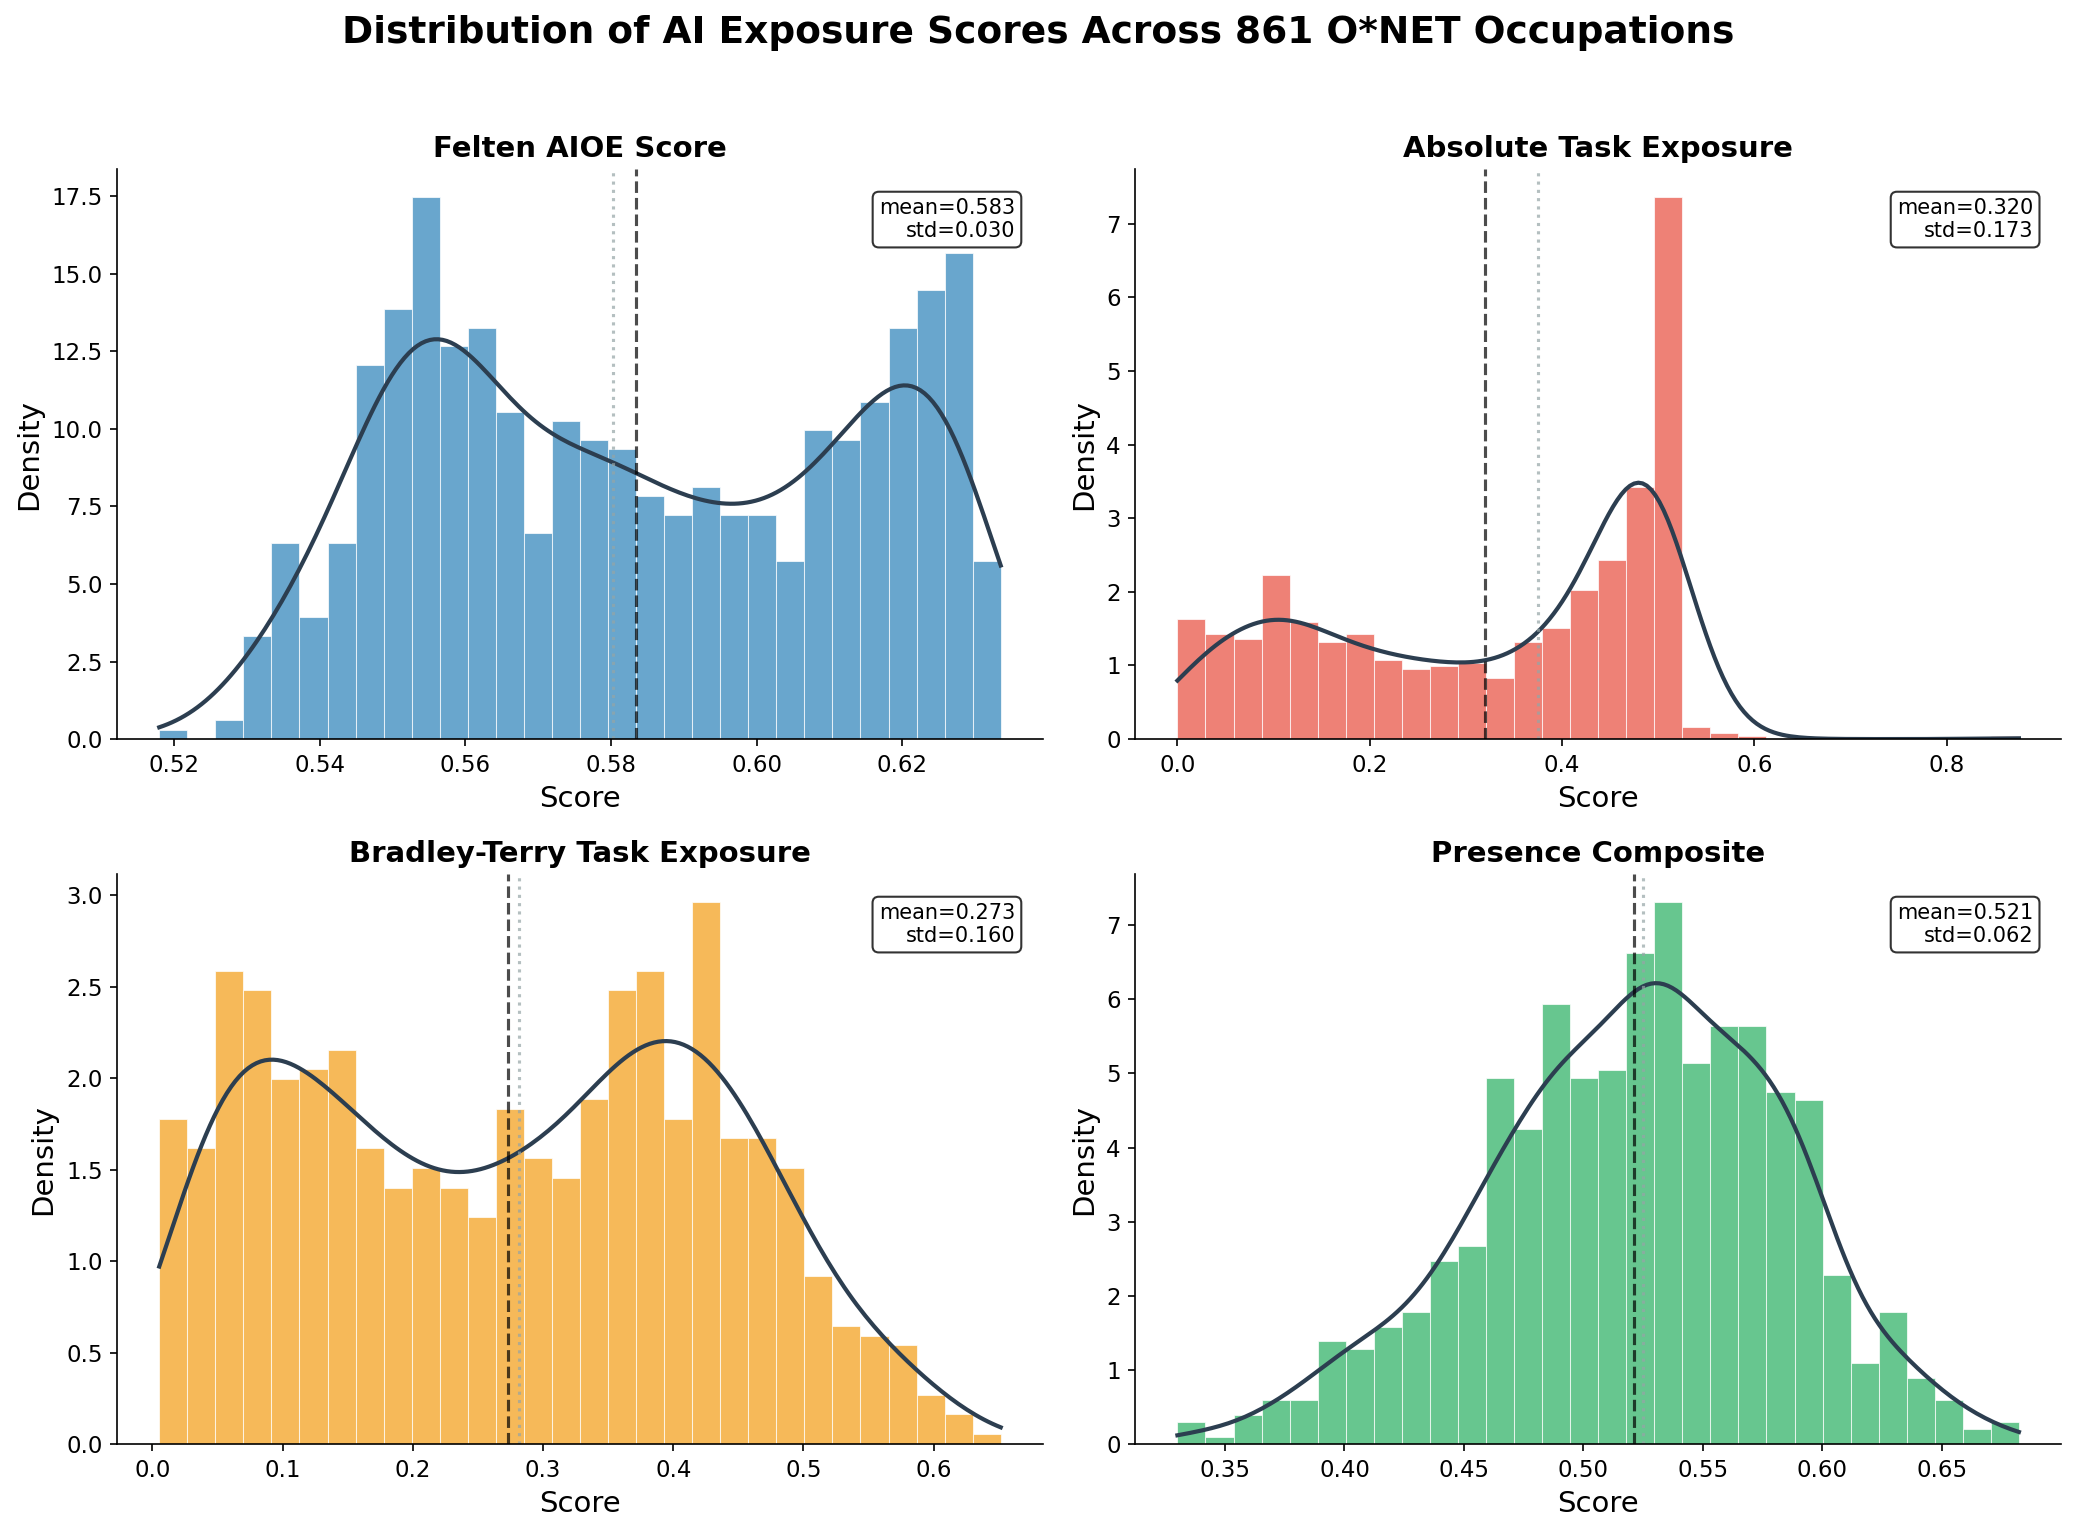

Saved: /Users/lukas/dev/20260208_tb8war__aisi-economy-index-v2/store/analysis/figures/score_distributions.png


In [ ]:
# Distribution of all four key scores across 861 occupations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

score_info = [
    ('felten_score', 'Felten AIOE Score', SECONDARY),
    ('task_exposure_mean', 'Absolute Task Exposure', ACCENT),
    ('task_exposure_bt_mean', 'Bradley-Terry Task Exposure', ORANGE),
    ('presence_composite', 'Presence Composite', GREEN),
]

for ax, (col, label, color) in zip(axes.flat, score_info):
    data = onet_df[col].dropna()
    
    n, bins, patches = ax.hist(data, bins=30, density=True, alpha=0.7,
                                color=color, edgecolor='white', linewidth=0.5)
    
    # KDE overlay
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=PRIMARY, linewidth=2)
    
    # Stats
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(data.median(), color=GREY_MED, linestyle=':', linewidth=1.5, alpha=0.7)
    
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    
    # Annotation
    ax.text(0.97, 0.95, f'mean={data.mean():.3f}\nstd={data.std():.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('Distribution of AI Exposure Scores Across 861 O*NET Occupations', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "score_distributions.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR / 'score_distributions.png'}")

**Observations:**
- **Felten AIOE** has a remarkably narrow range (0.52--0.63). Since it derives from broad cognitive abilities mapped to AI applications, most occupations end up similarly scored. This limits its discriminatory power between occupations.
- **Absolute Task Exposure** shows a prominent spike at 0.5, corresponding to occupations where tasks are roughly evenly split between "no exposure" and "partial/full exposure." The distribution is effectively bimodal.
- **Bradley-Terry Task Exposure** provides a more continuous ranking via pairwise comparisons. It is right-skewed: most occupations have low-to-moderate task exposure, with a long tail of highly exposed occupations.
- **Presence Composite** is approximately normal, centered around 0.52. This captures physical, emotional, and creative human presence requirements that resist automation.

## 4. AI Exposure by O\*NET Major Group

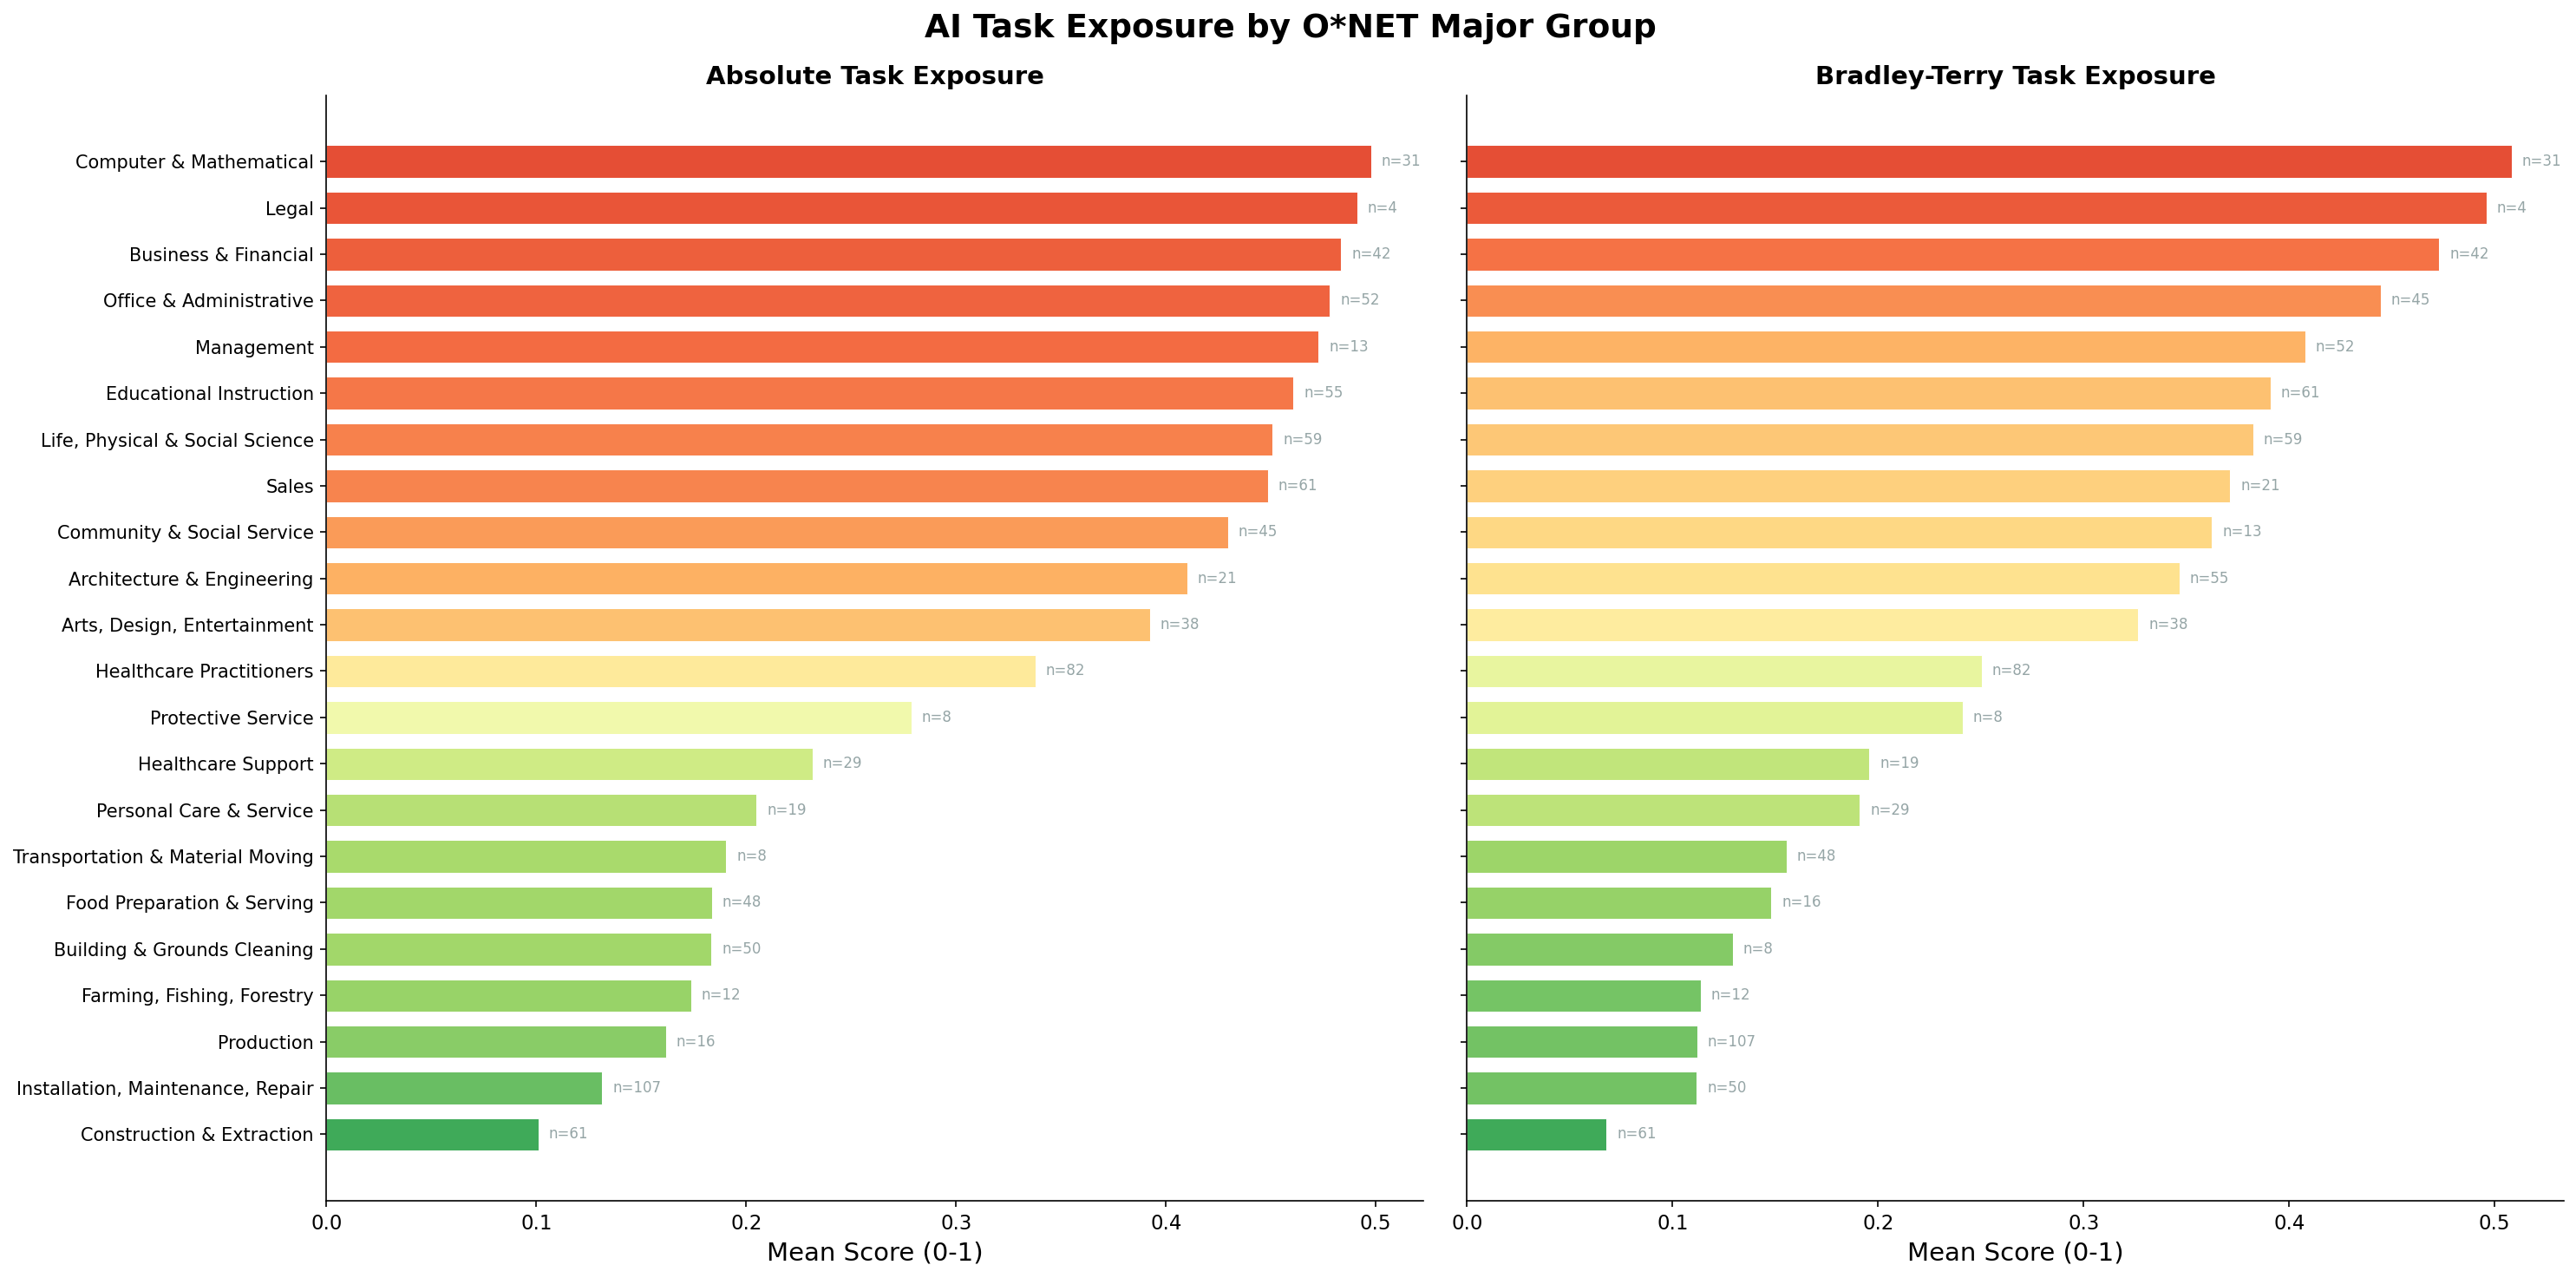

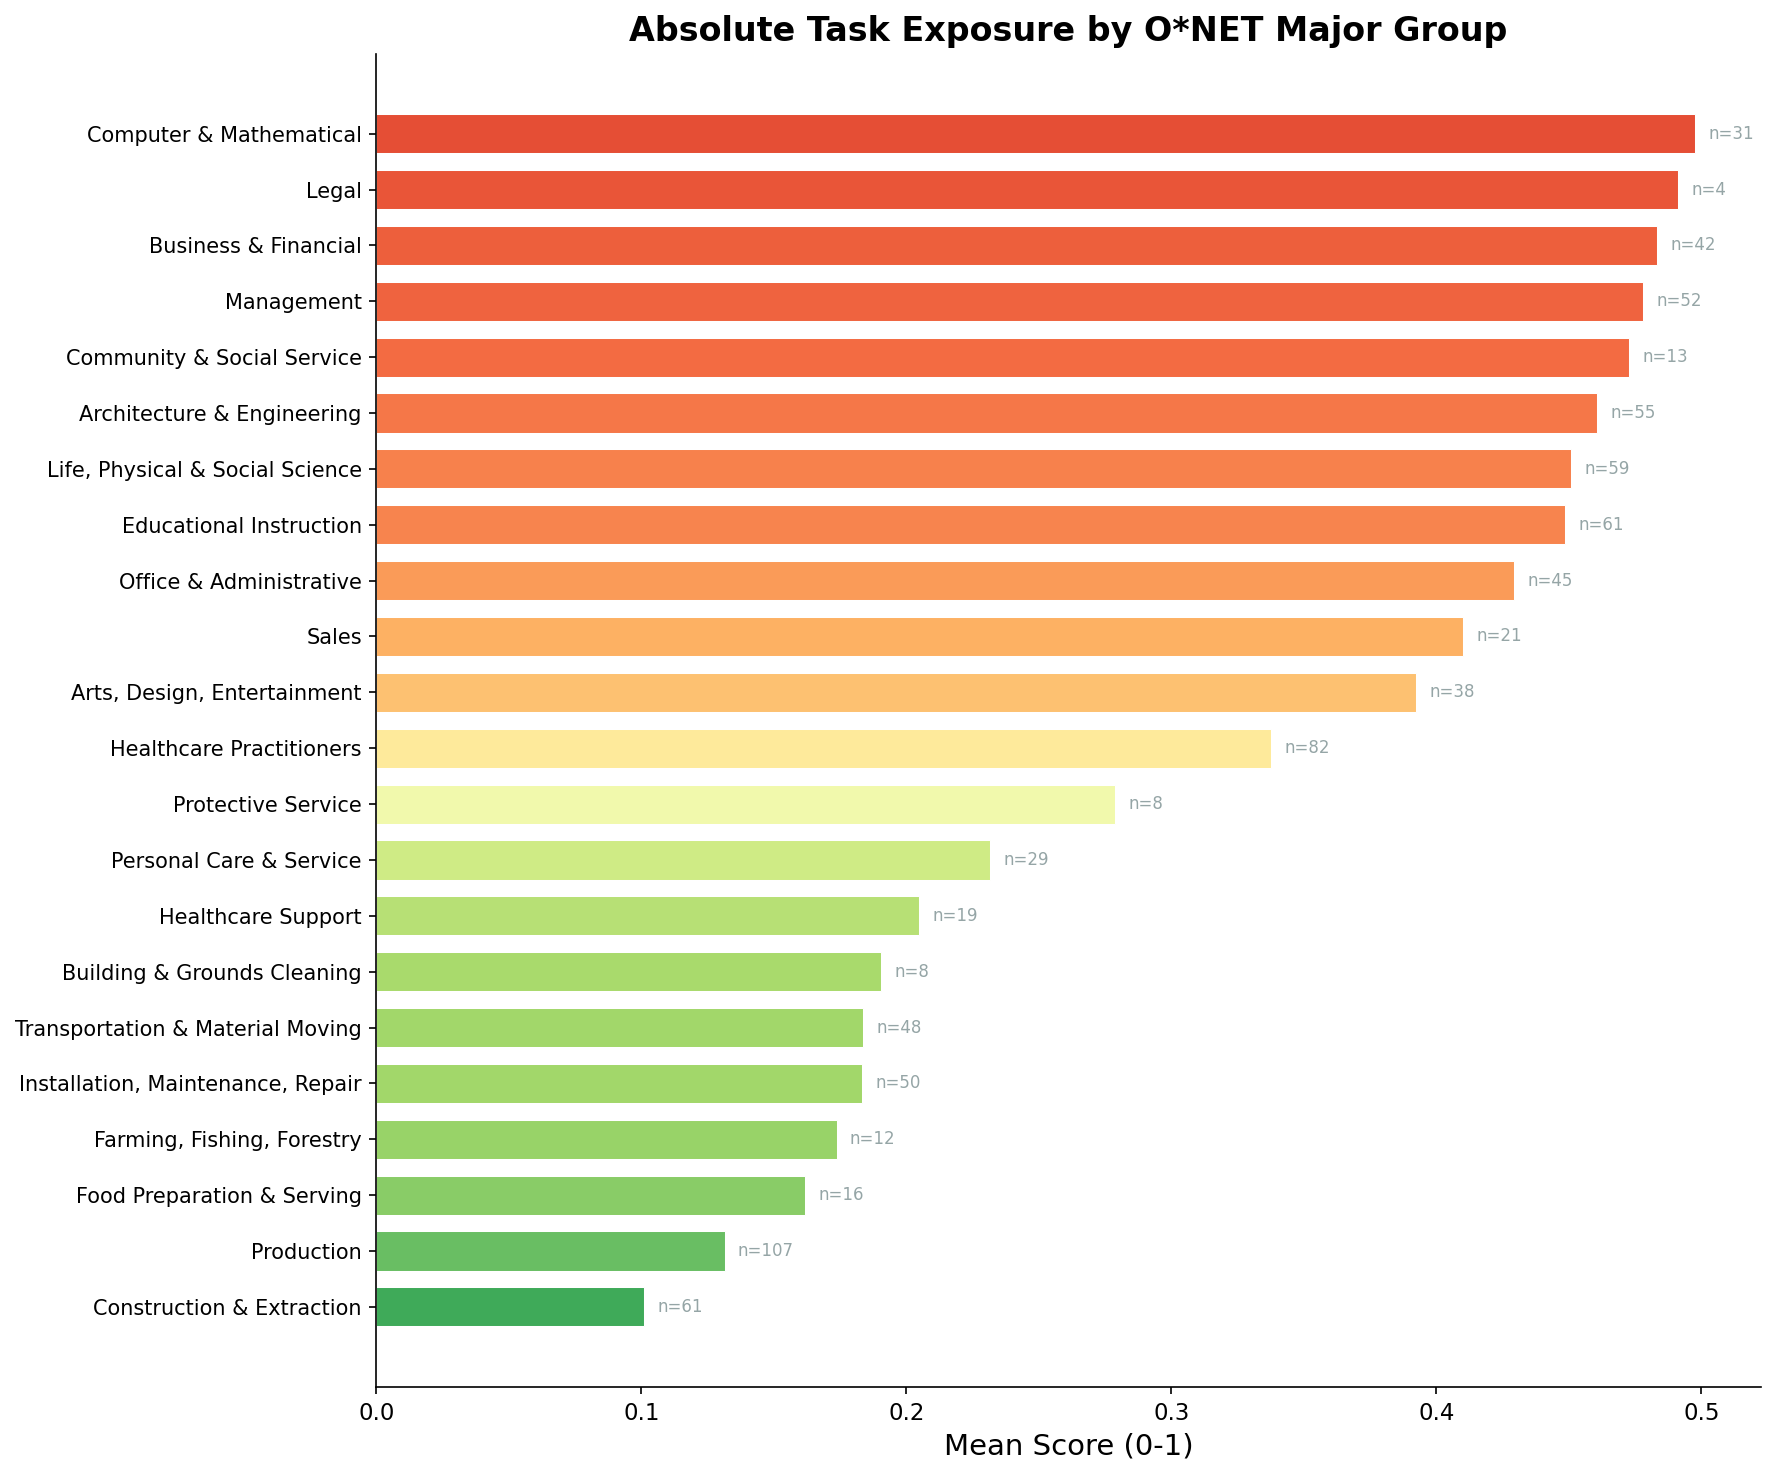

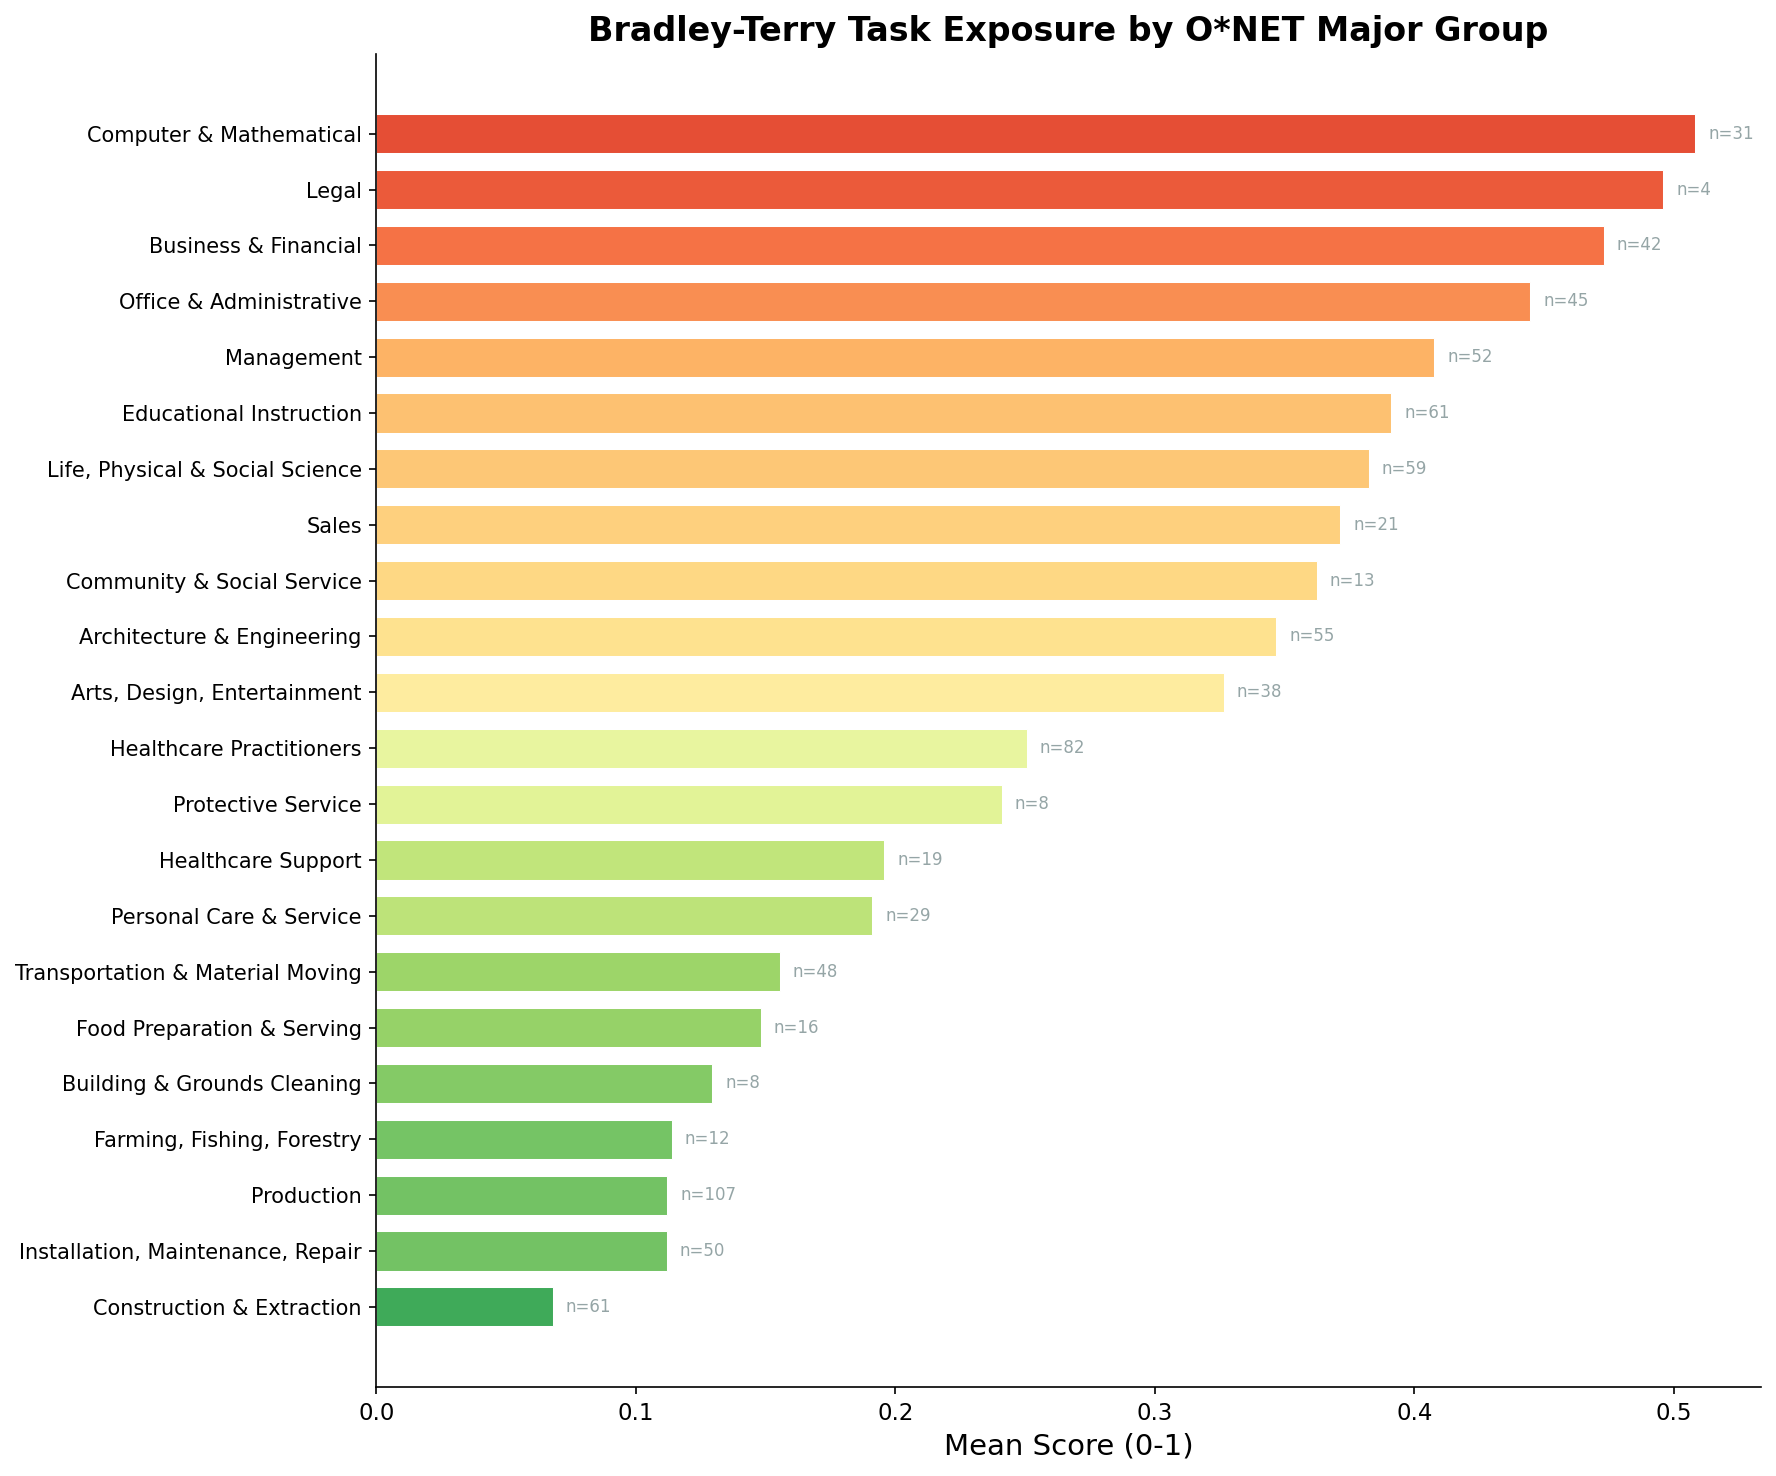

In [ ]:
# Aggregate scores by O*NET major group
group_stats = onet_df.groupby('major_group').agg(
    n_occupations=('onet_code', 'count'),
    felten_mean=('felten_score', 'mean'),
    te_abs_mean=('task_exposure_mean', 'mean'),
    te_bt_mean=('task_exposure_bt_mean', 'mean'),
    presence_mean=('presence_composite', 'mean'),
).reset_index()

# --- Side-by-side: Absolute vs Bradley-Terry ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = 'te_abs_mean' if key == 'absolute' else 'te_bt_mean'
    stats_sorted = group_stats.sort_values(col, ascending=True)
    y_pos = np.arange(len(stats_sorted))
    
    norm_vals = (stats_sorted[col] - stats_sorted[col].min()) / (stats_sorted[col].max() - stats_sorted[col].min() + 0.001)
    colors = plt.cm.RdYlGn_r(norm_vals * 0.7 + 0.15)
    
    ax.barh(y_pos, stats_sorted[col], color=colors, edgecolor='white', linewidth=0.5, height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats_sorted['major_group'], fontsize=10)
    ax.set_xlabel('Mean Score (0-1)')
    ax.set_title(sv['label'], fontsize=14, fontweight='bold')
    
    for i, (_, row) in enumerate(stats_sorted.iterrows()):
        ax.text(row[col] + 0.005, i, f"n={row['n_occupations']}", fontsize=8, va='center', color=GREY_MED)

fig.suptitle('AI Task Exposure by O*NET Major Group', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / "exposure_by_major_group_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Individual plots ---
for key, sv in SCORE_VARIANTS.items():
    col = 'te_abs_mean' if key == 'absolute' else 'te_bt_mean'
    stats_sorted = group_stats.sort_values(col, ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    y_pos = np.arange(len(stats_sorted))
    norm_vals = (stats_sorted[col] - stats_sorted[col].min()) / (stats_sorted[col].max() - stats_sorted[col].min() + 0.001)
    colors = plt.cm.RdYlGn_r(norm_vals * 0.7 + 0.15)
    
    ax.barh(y_pos, stats_sorted[col], color=colors, edgecolor='white', linewidth=0.5, height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats_sorted['major_group'], fontsize=10)
    ax.set_xlabel('Mean Score (0-1)')
    ax.set_title(f'{sv["label"]} by O*NET Major Group', fontsize=16, fontweight='bold')
    
    for i, (_, row) in enumerate(stats_sorted.iterrows()):
        ax.text(row[col] + 0.005, i, f"n={row['n_occupations']}", fontsize=8, va='center', color=GREY_MED)
    
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"exposure_by_major_group_{key}.png", dpi=300, bbox_inches='tight')
    plt.show()

**Observations:**
- The **Felten AIOE** bars (blue) are strikingly uniform across major groups, barely varying between 0.55 and 0.63. This confirms that the ability-based Felten methodology does not discriminate well between occupational families, since most occupations draw on a similar mix of cognitive abilities.
- **Task Exposure** (red) tells a far more differentiated story. Legal, Computer & Mathematical, and Business & Financial occupations have the highest task-level AI exposure (~0.45--0.55), while Construction, Building & Grounds Cleaning, and Farming score below 0.15.
- The divergence between the two metrics is itself informative: groups like Construction & Extraction have relatively high Felten scores but very low task exposure, suggesting that while the underlying abilities may overlap with AI capabilities, the actual tasks performed are not easily automatable.
- **Legal** (n=4) has the highest exposure on both metrics, but the small number of occupations in this group means it should be interpreted cautiously.

## 5. Top and Bottom Occupations by Task Exposure

Since task exposure is the most discriminating metric, let's examine the individual occupations at the extremes for both the absolute and Bradley-Terry scoring methods.

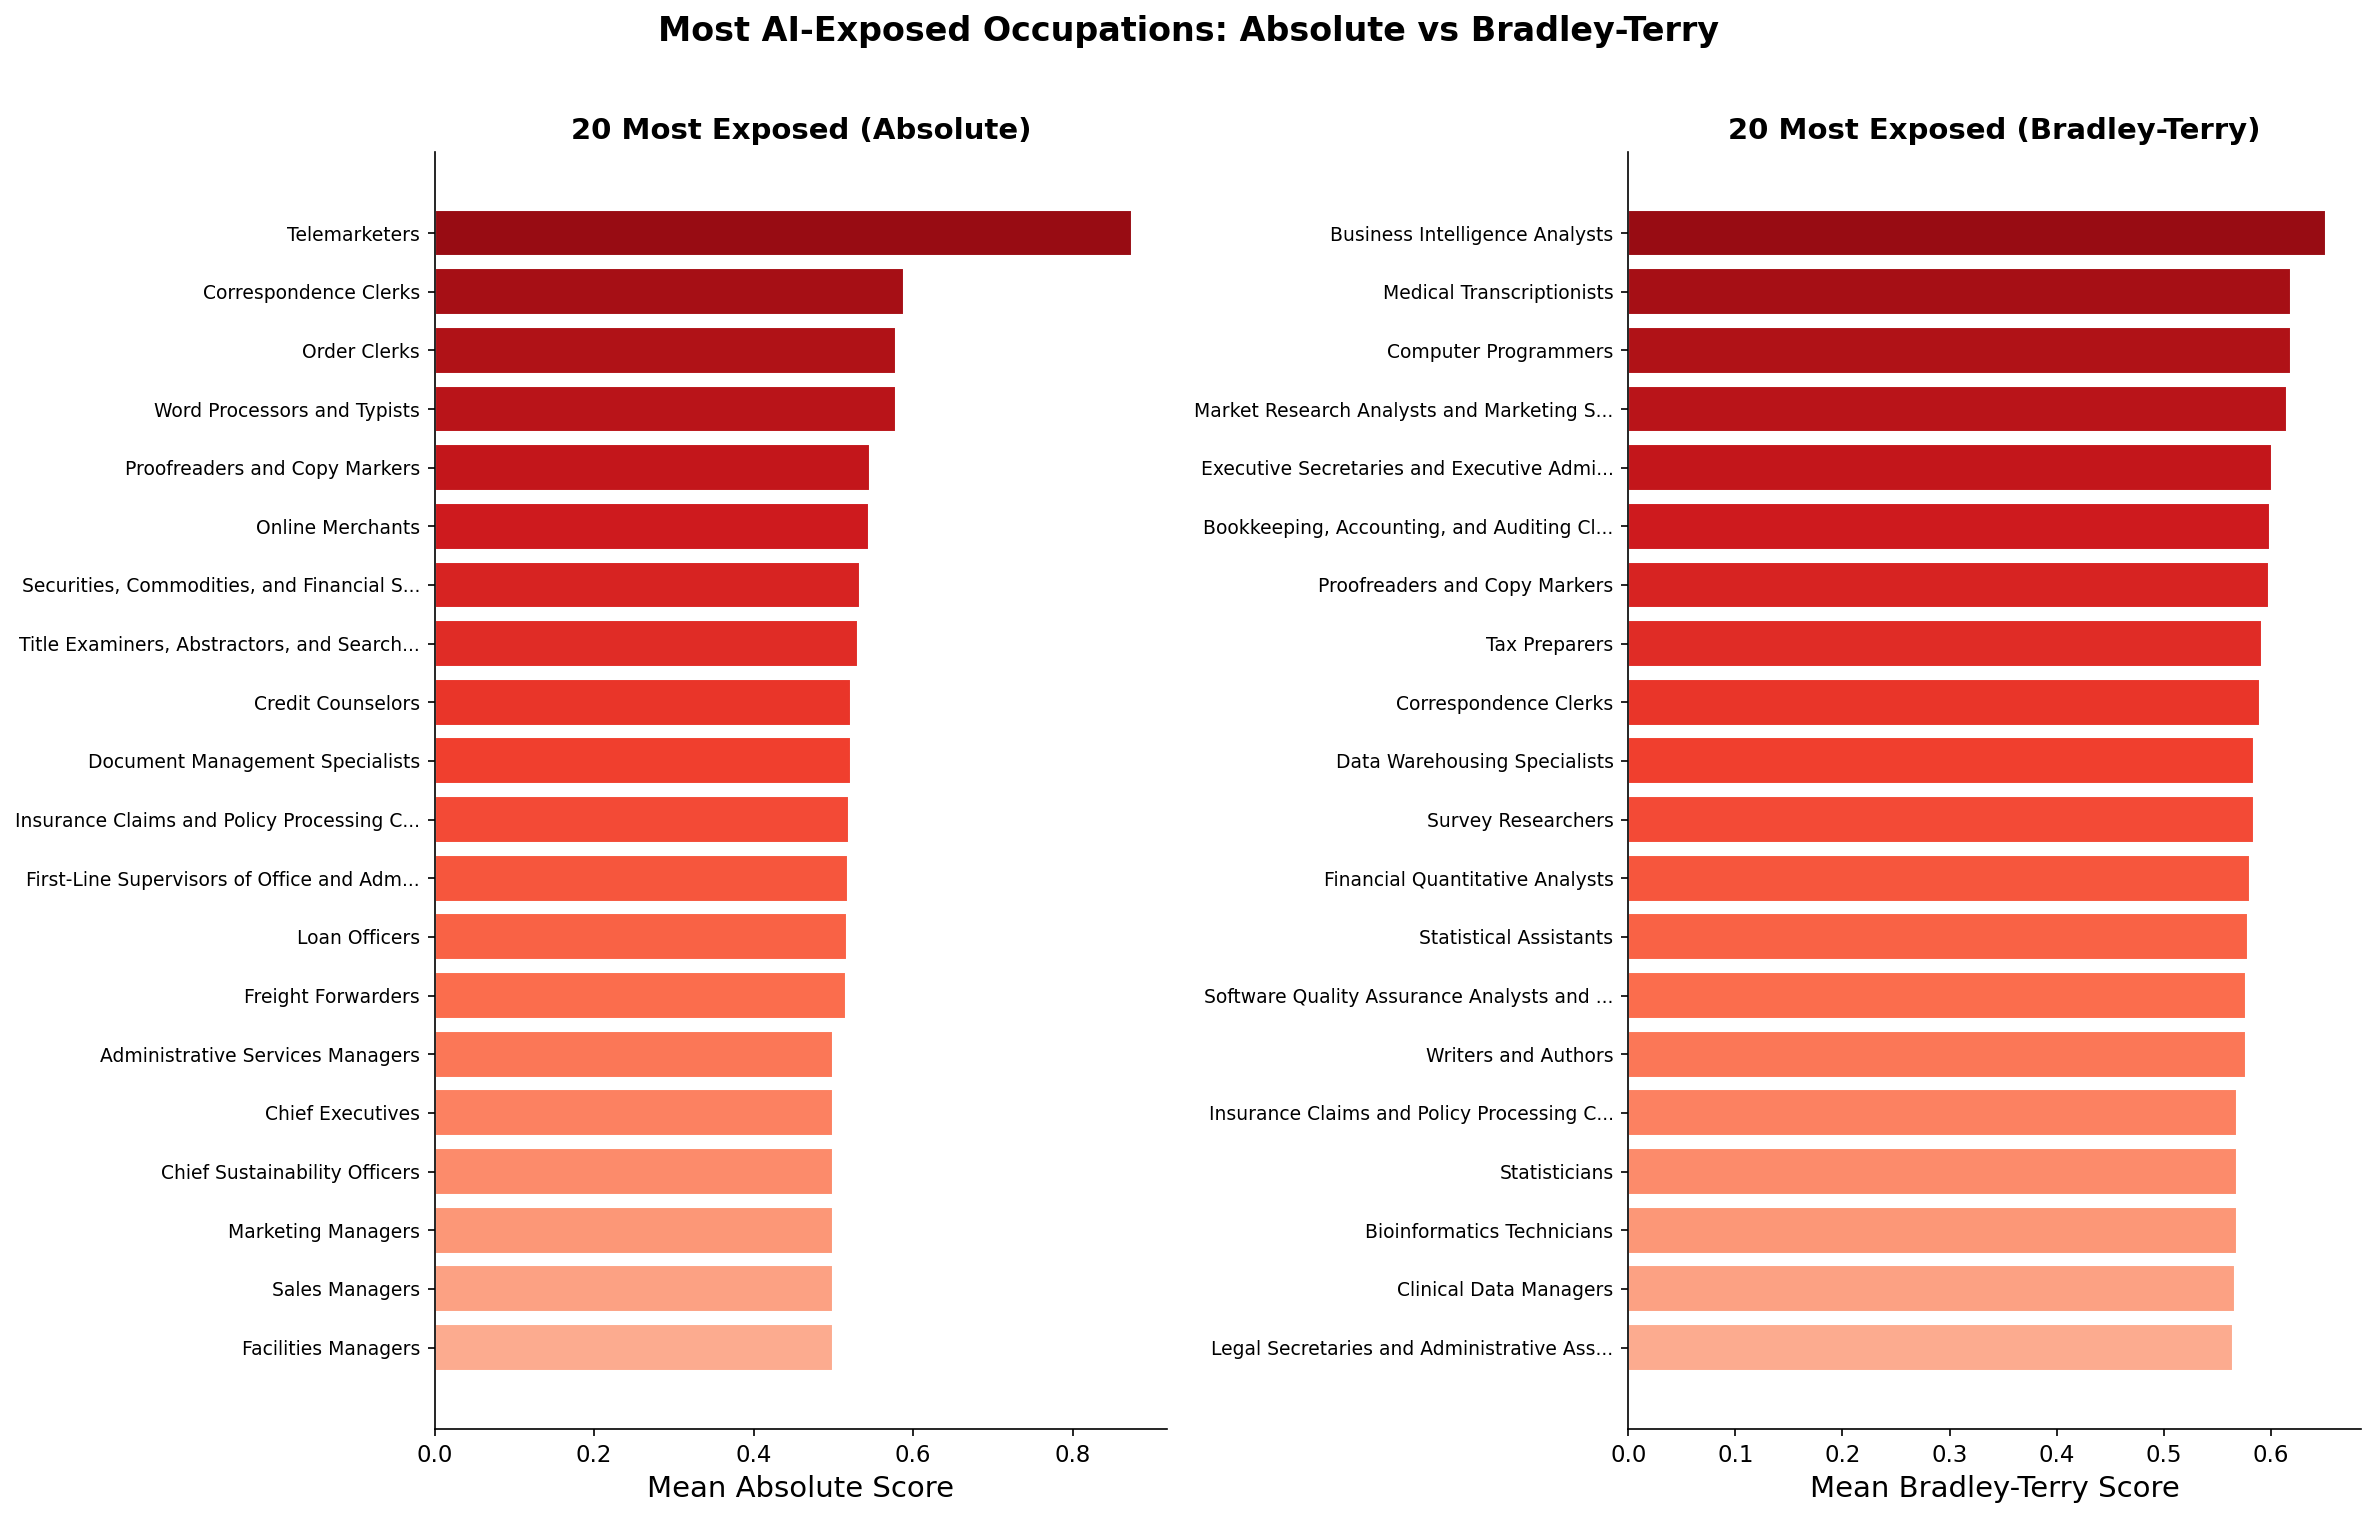

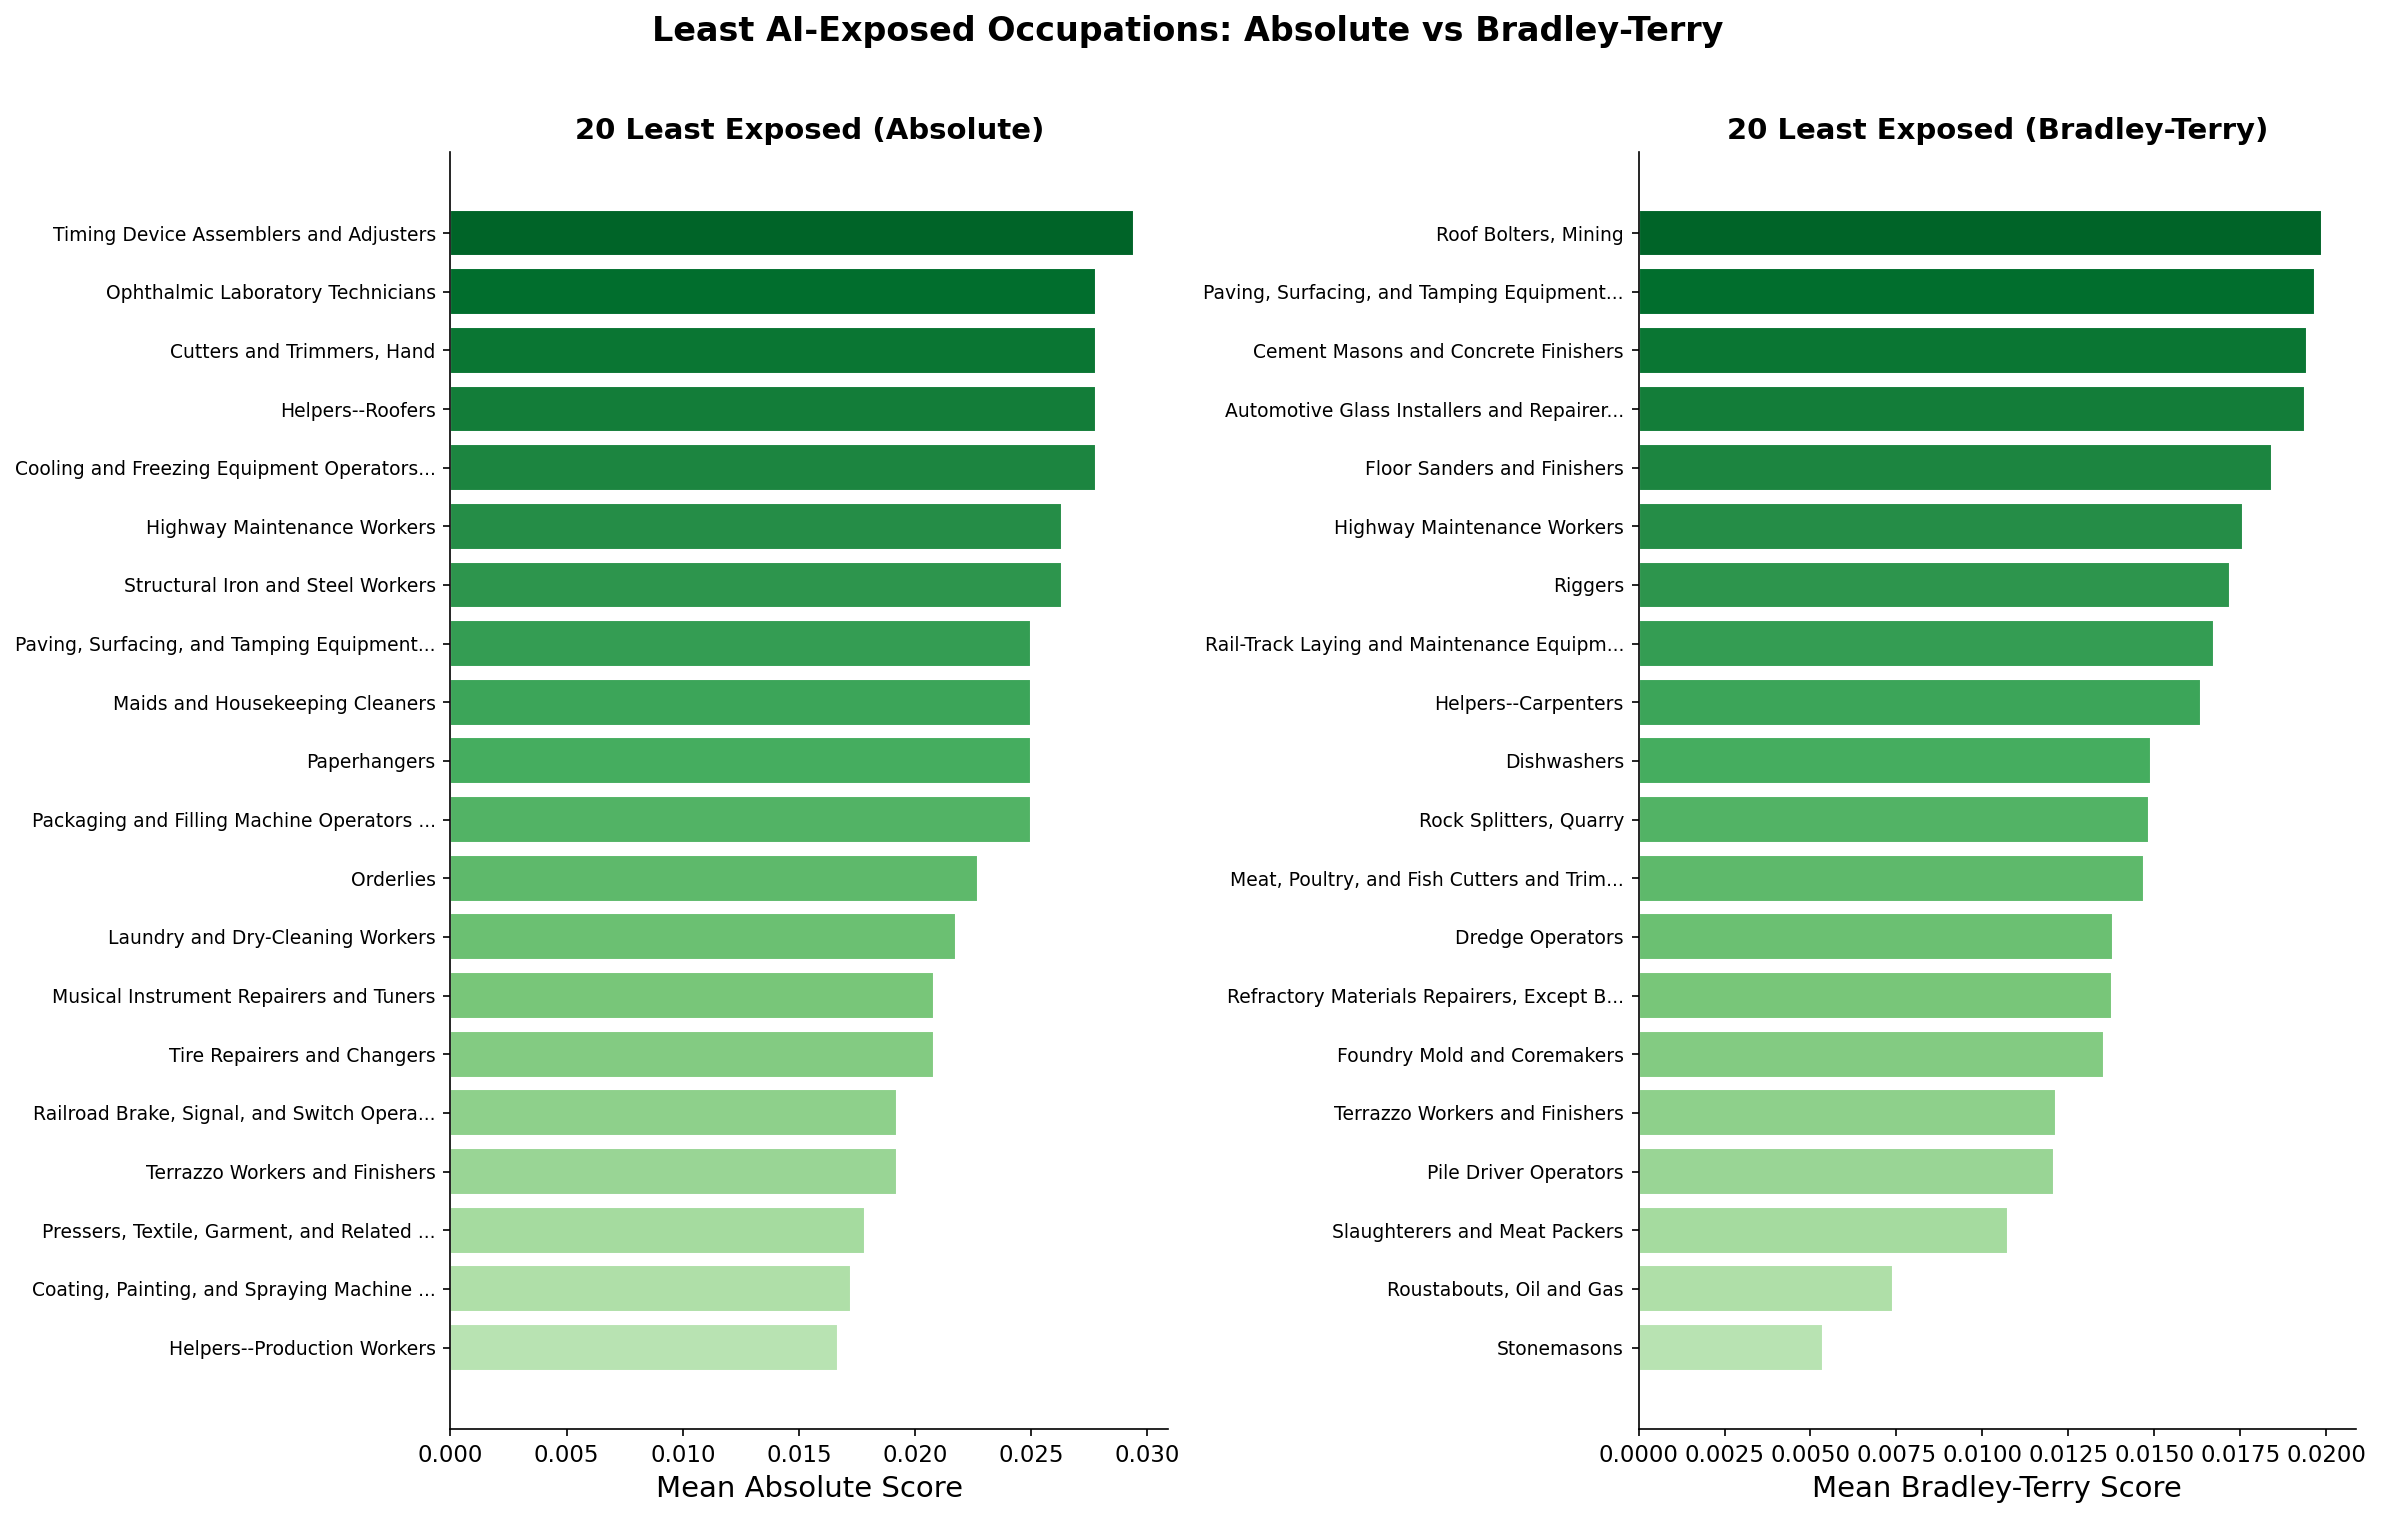

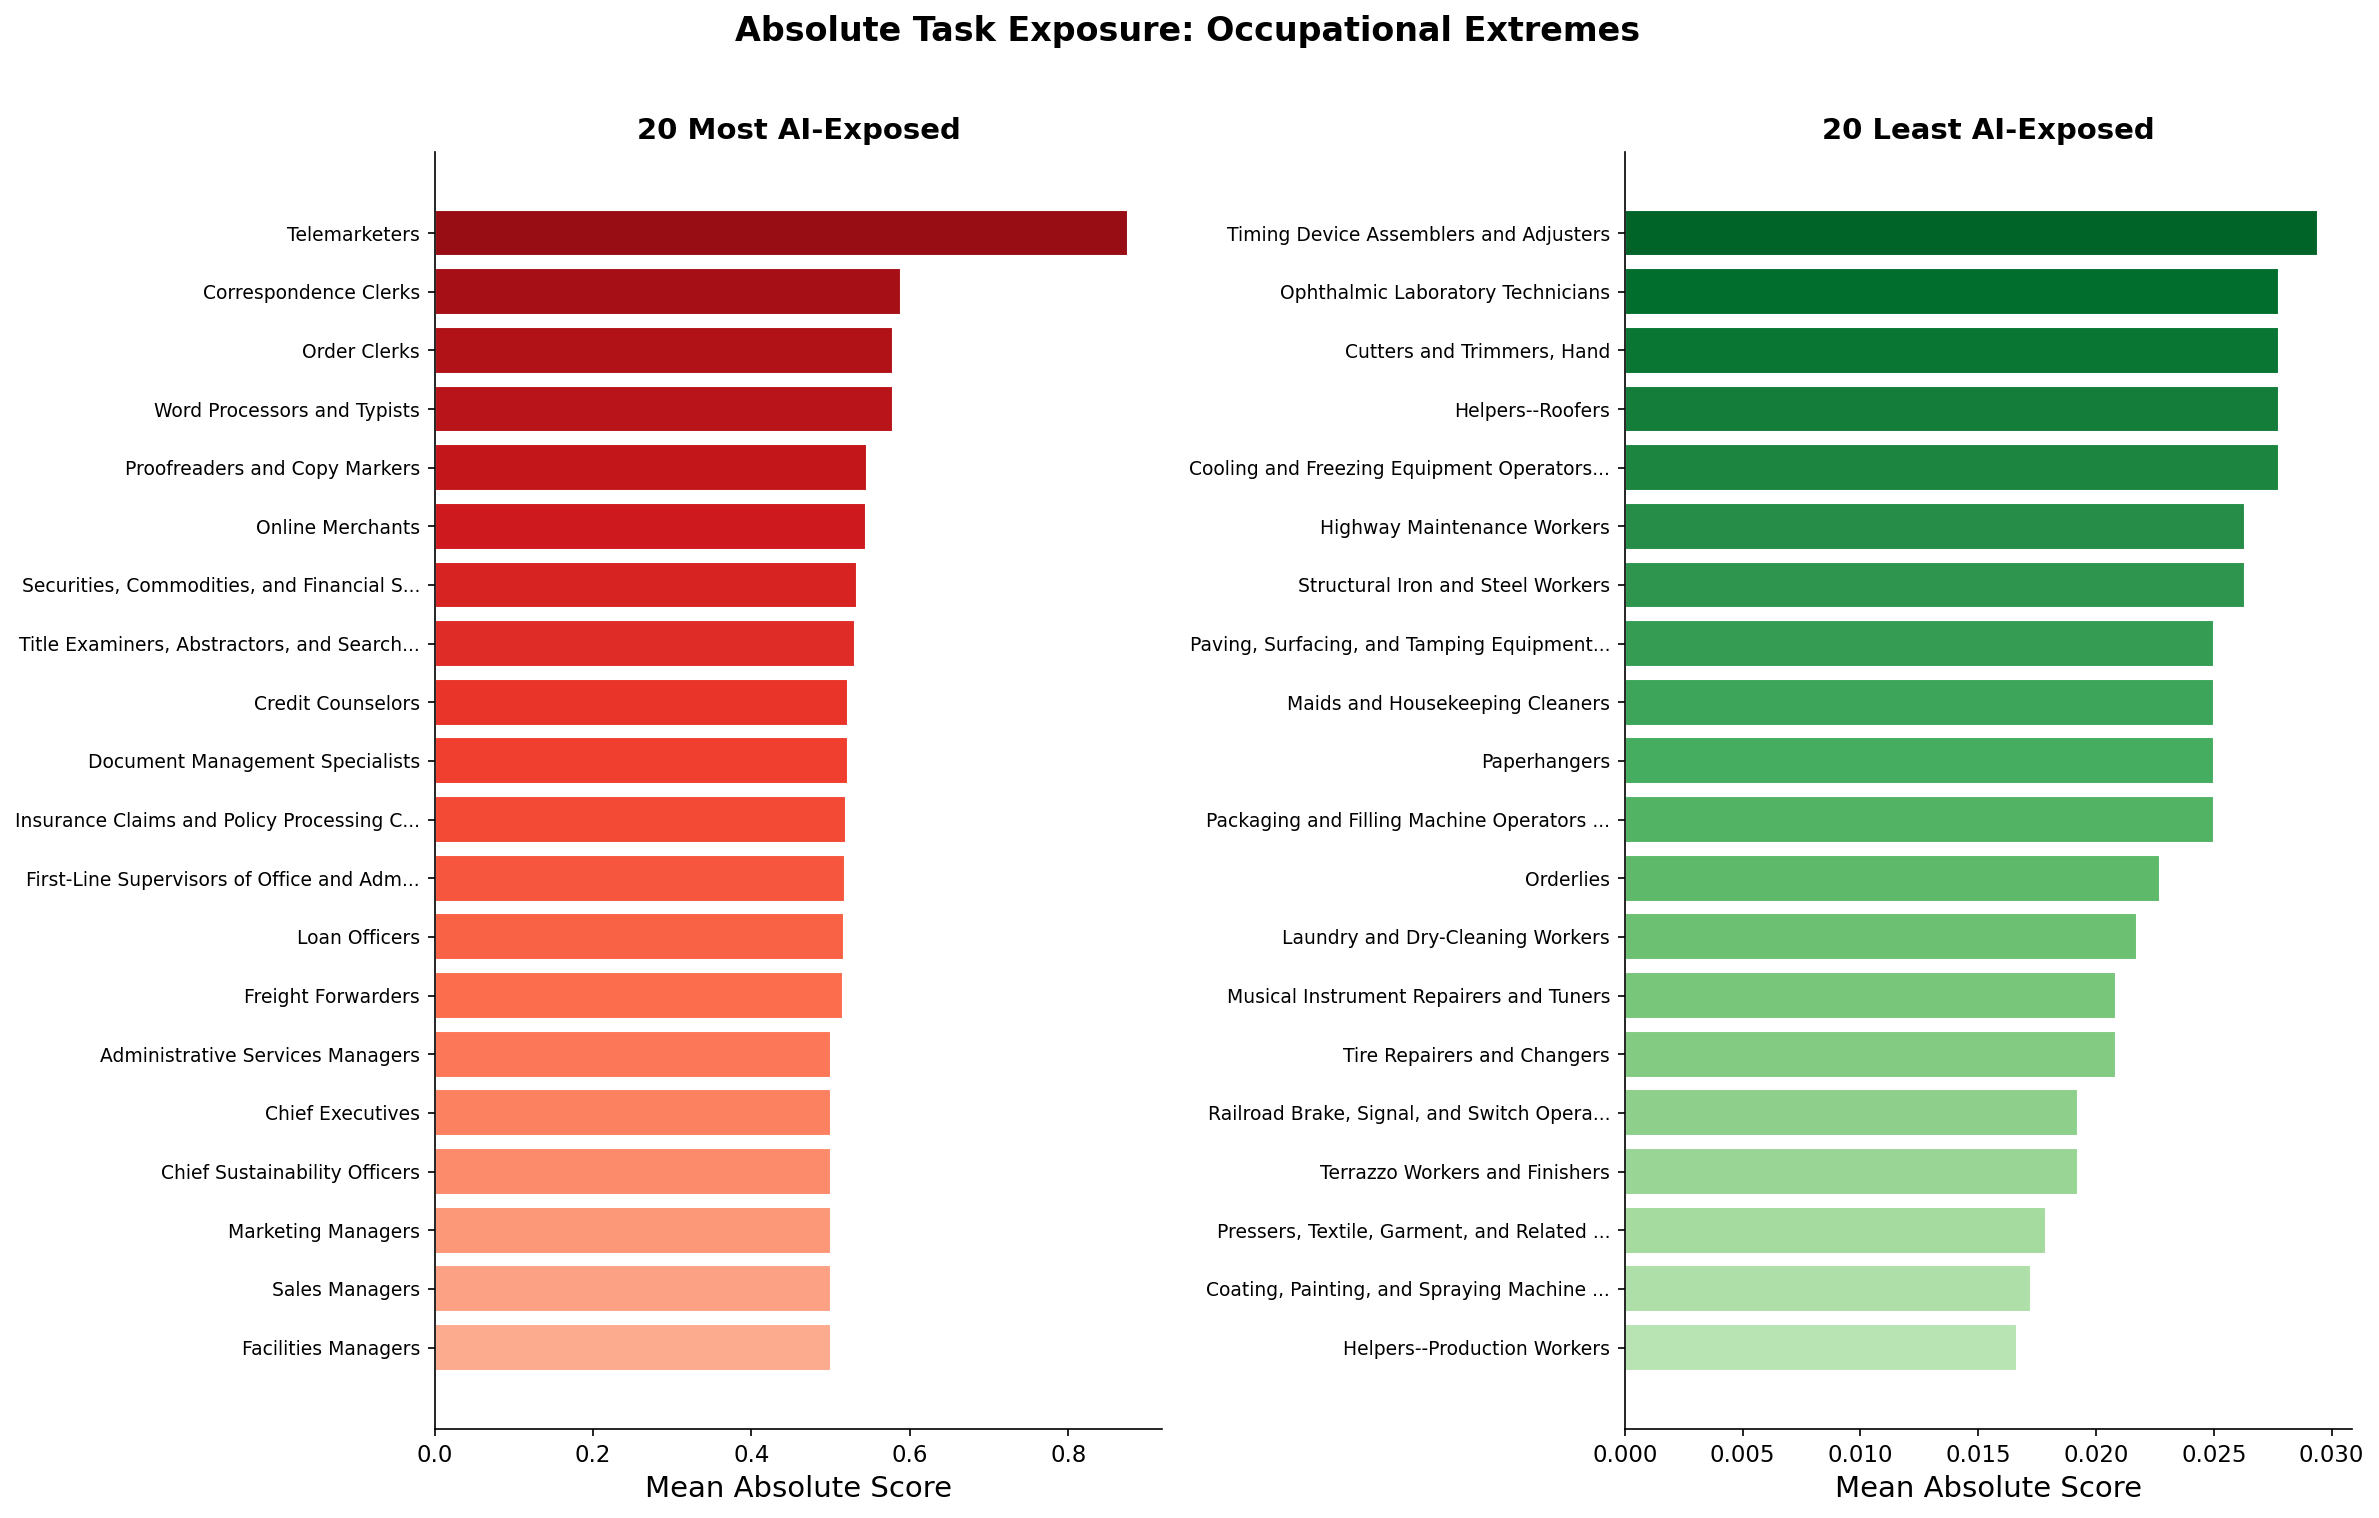

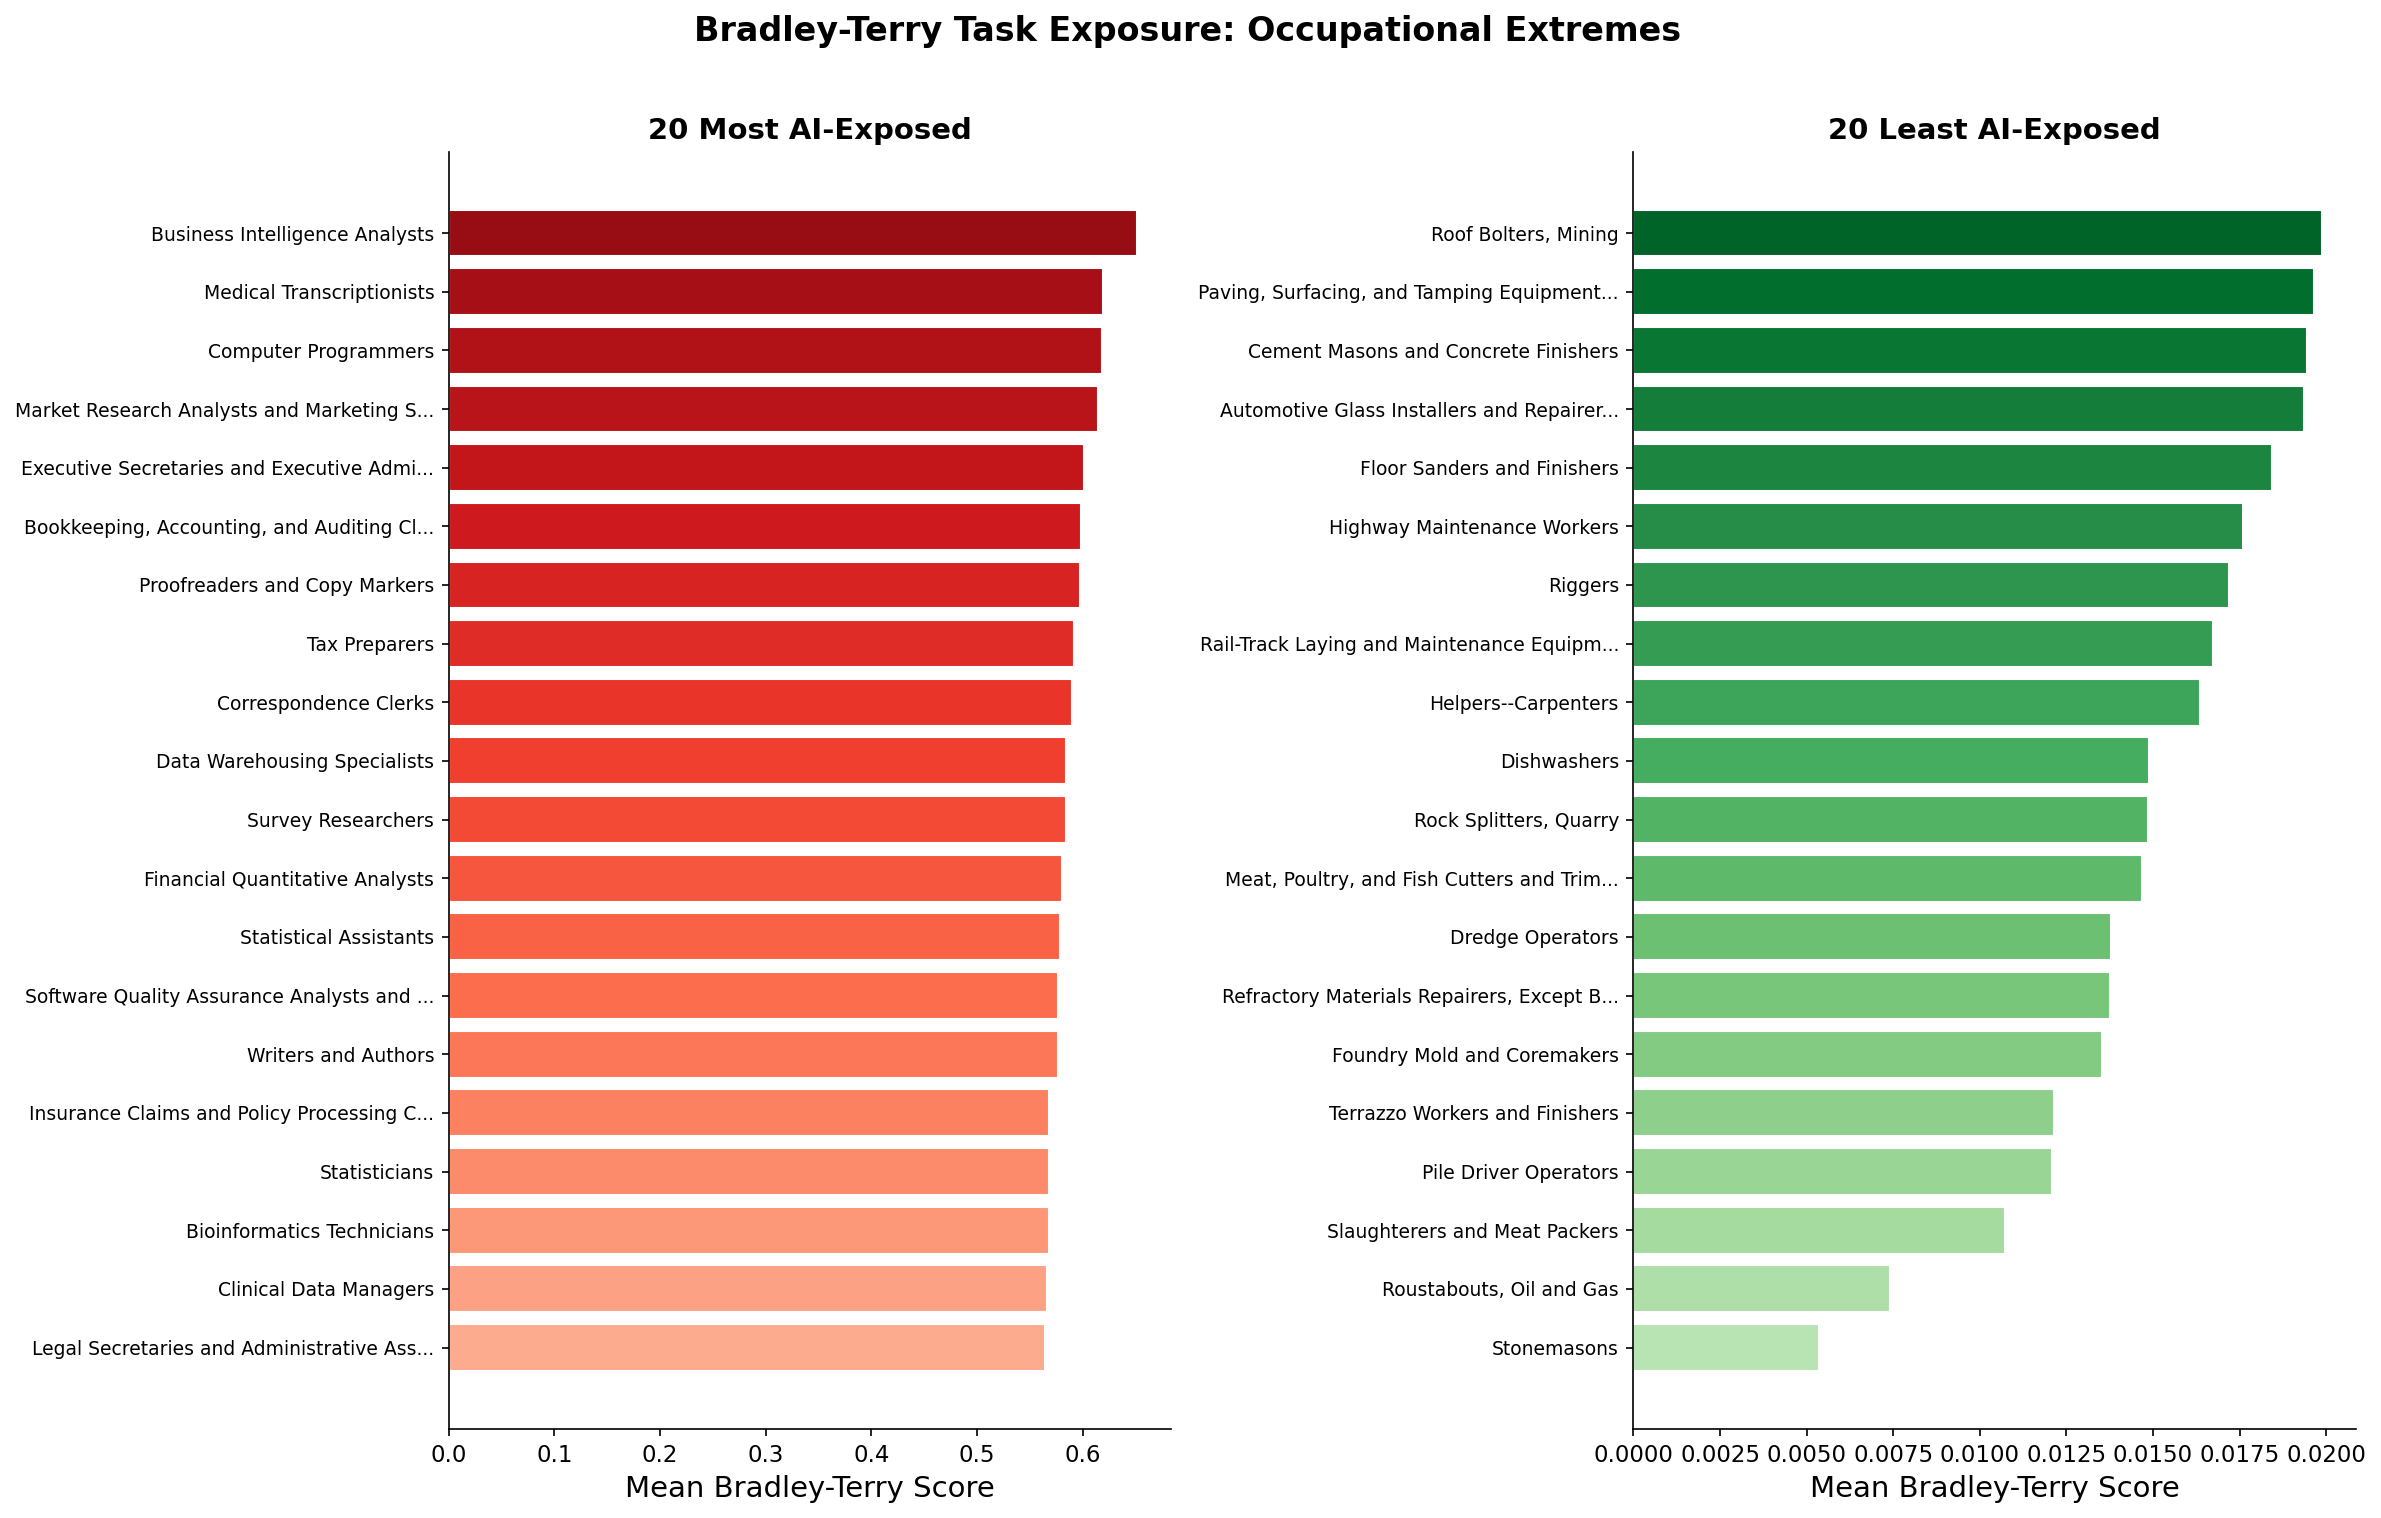

In [ ]:
# --- Side-by-side: Top 20 occupations, absolute vs BT ---
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = sv['col']
    top20 = onet_df.nlargest(20, col).sort_values(col, ascending=True)
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top20)))
    ax.barh(range(len(top20)), top20[col], color=colors, edgecolor='white')
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels([t[:40] + '...' if len(str(t)) > 40 else t for t in top20['title']], fontsize=9)
    ax.set_xlabel(f'Mean {sv["label_short"]} Score')
    ax.set_title(f'20 Most Exposed ({sv["label_short"]})', fontsize=14, fontweight='bold')

fig.suptitle('Most AI-Exposed Occupations: Absolute vs Bradley-Terry', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "top_occupations_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Side-by-side: Bottom 20 occupations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = sv['col']
    bottom20 = onet_df[onet_df[col] > 0].nsmallest(20, col).sort_values(col, ascending=True)
    colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(bottom20)))
    ax.barh(range(len(bottom20)), bottom20[col], color=colors, edgecolor='white')
    ax.set_yticks(range(len(bottom20)))
    ax.set_yticklabels([t[:40] + '...' if len(str(t)) > 40 else t for t in bottom20['title']], fontsize=9)
    ax.set_xlabel(f'Mean {sv["label_short"]} Score')
    ax.set_title(f'20 Least Exposed ({sv["label_short"]})', fontsize=14, fontweight='bold')

fig.suptitle('Least AI-Exposed Occupations: Absolute vs Bradley-Terry', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "bottom_occupations_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Individual plots ---
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    
    top20 = onet_df.nlargest(20, col).sort_values(col, ascending=True)
    ax1 = axes[0]
    colors_top = plt.cm.Reds(np.linspace(0.3, 0.9, len(top20)))
    ax1.barh(range(len(top20)), top20[col], color=colors_top, edgecolor='white')
    ax1.set_yticks(range(len(top20)))
    ax1.set_yticklabels([t[:40] + '...' if len(str(t)) > 40 else t for t in top20['title']], fontsize=9)
    ax1.set_xlabel(f'Mean {sv["label_short"]} Score')
    ax1.set_title('20 Most AI-Exposed', fontsize=14, fontweight='bold')
    
    bottom20 = onet_df[onet_df[col] > 0].nsmallest(20, col).sort_values(col, ascending=True)
    ax2 = axes[1]
    colors_bot = plt.cm.Greens(np.linspace(0.3, 0.9, len(bottom20)))
    ax2.barh(range(len(bottom20)), bottom20[col], color=colors_bot, edgecolor='white')
    ax2.set_yticks(range(len(bottom20)))
    ax2.set_yticklabels([t[:40] + '...' if len(str(t)) > 40 else t for t in bottom20['title']], fontsize=9)
    ax2.set_xlabel(f'Mean {sv["label_short"]} Score')
    ax2.set_title('20 Least AI-Exposed', fontsize=14, fontweight='bold')
    
    fig.suptitle(f'{sv["label"]}: Occupational Extremes', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"top_bottom_occupations_{key}.png", dpi=300, bbox_inches='tight')
    plt.show()

**Observations:**
- The **most AI-exposed occupations** are overwhelmingly routine cognitive/administrative roles: Telemarketers (0.88), Correspondence Clerks, Order Clerks, Word Processors. These occupations involve tasks that are largely text-based, repetitive, and rule-following.
- The **least exposed** occupations involve physical dexterity, manual labor, or specialized sensory work: Timing Device Assemblers, Ophthalmic Lab Technicians, Roofers, Highway Maintenance Workers.
- The scale difference is striking: the most exposed occupation scores ~0.88 while the least scores ~0.003, a 300x ratio. AI task exposure is not a continuum but a sharp divide between cognitive-routine and physical-manual work.

## 6. Geographic Variation: AI Exposure Across the UK

Choropleth maps of AI exposure at Local Authority District level, weighted by the occupational composition of job ads in each area.

In [ ]:
# Load LAD boundaries and merge with exposure data
gdf = gpd.read_file(LAD_BOUNDARY_PATH)
print(f"Loaded {len(gdf)} LAD polygons")
print(f"CRS: {gdf.crs}")
print(f"Columns: {gdf.columns.tolist()}")

# Merge
merged = gdf.merge(geo_df, on='LAD22CD', how='left')
matched = merged['felten_score'].notna().sum()
print(f"Matched {matched} of {len(gdf)} LADs to exposure data")

# Simplify geometry for faster rendering
merged['geometry'] = merged['geometry'].simplify(tolerance=100)

# Show score ranges at LAD level
for col in ['felten_score', 'task_exposure_mean', 'task_exposure_bt_mean', 'presence_composite']:
    vals = merged[col].dropna()
    print(f"\n{col} (LAD): range [{vals.min():.4f}, {vals.max():.4f}], spread={vals.max()-vals.min():.4f}")

Loaded 374 LAD polygons
CRS: EPSG:27700
Columns: ['FID', 'LAD22CD', 'LAD22NM', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']
Matched 373 of 374 LADs to exposure data



felten_score (LAD): range [0.5718, 0.6109], spread=0.0390

task_exposure_mean (LAD): range [0.2775, 0.4643], spread=0.1868

task_exposure_bt_mean (LAD): range [0.2301, 0.4499], spread=0.2198

presence_composite (LAD): range [0.4926, 0.5359], spread=0.0433


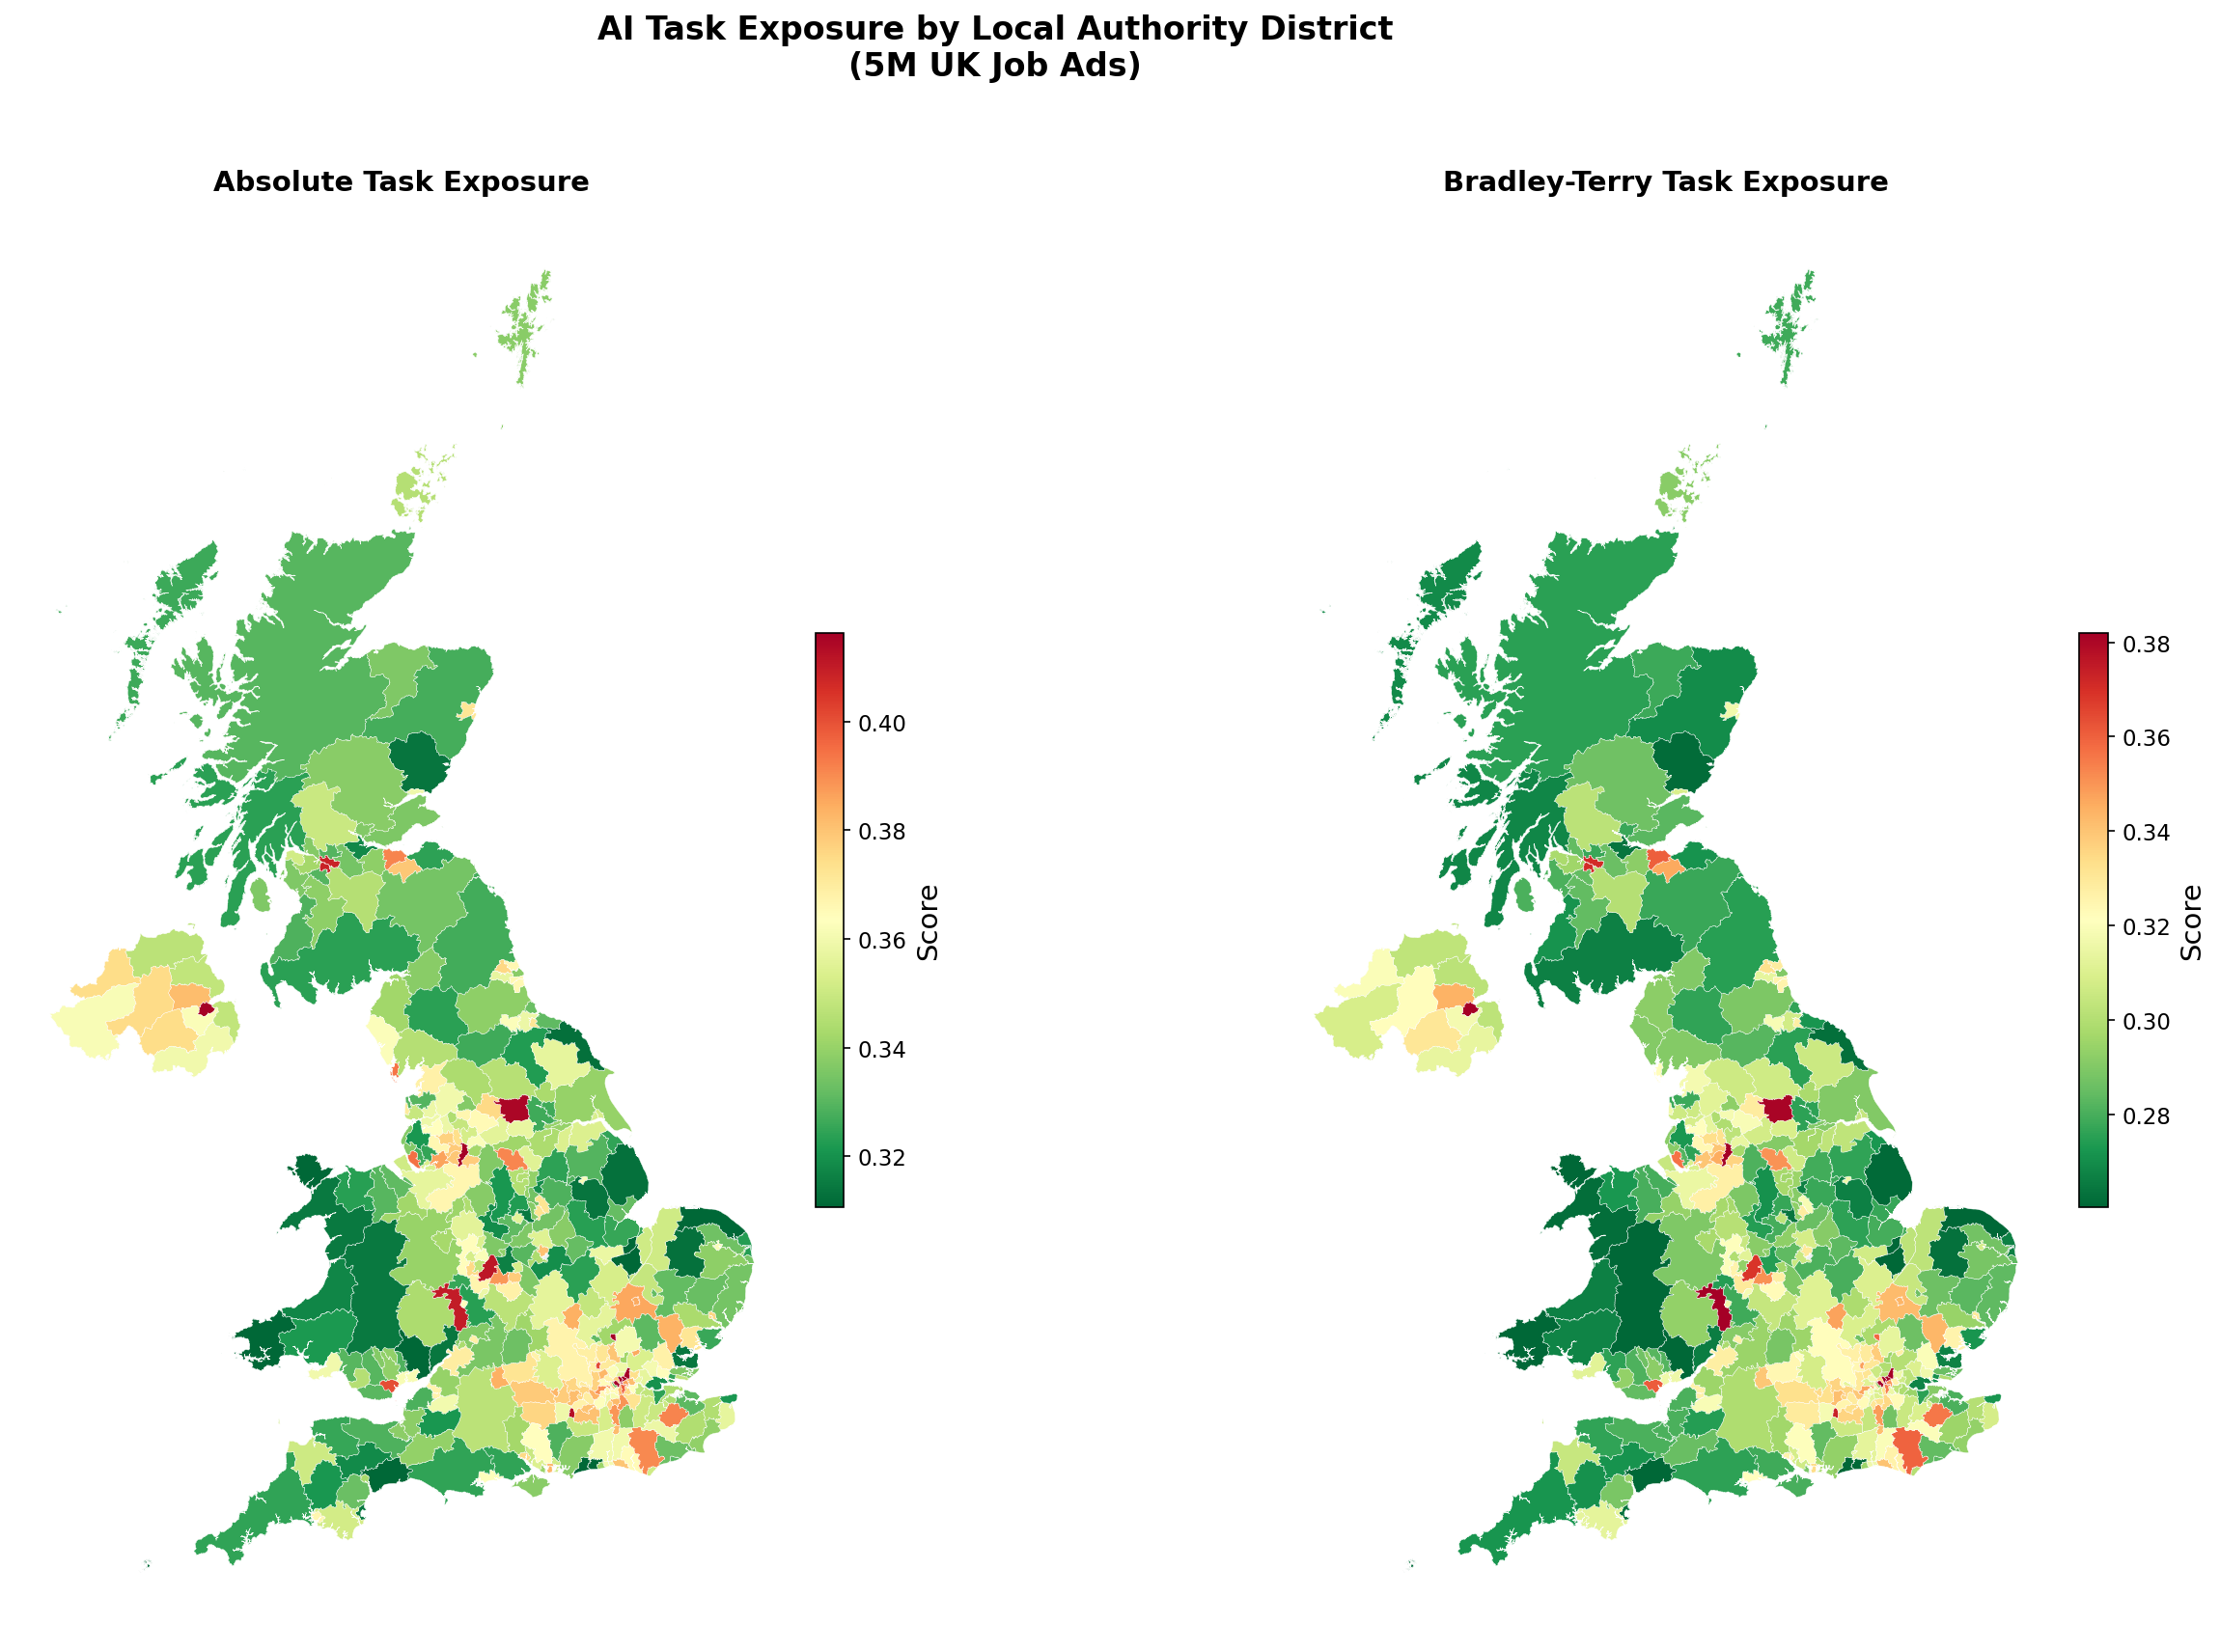

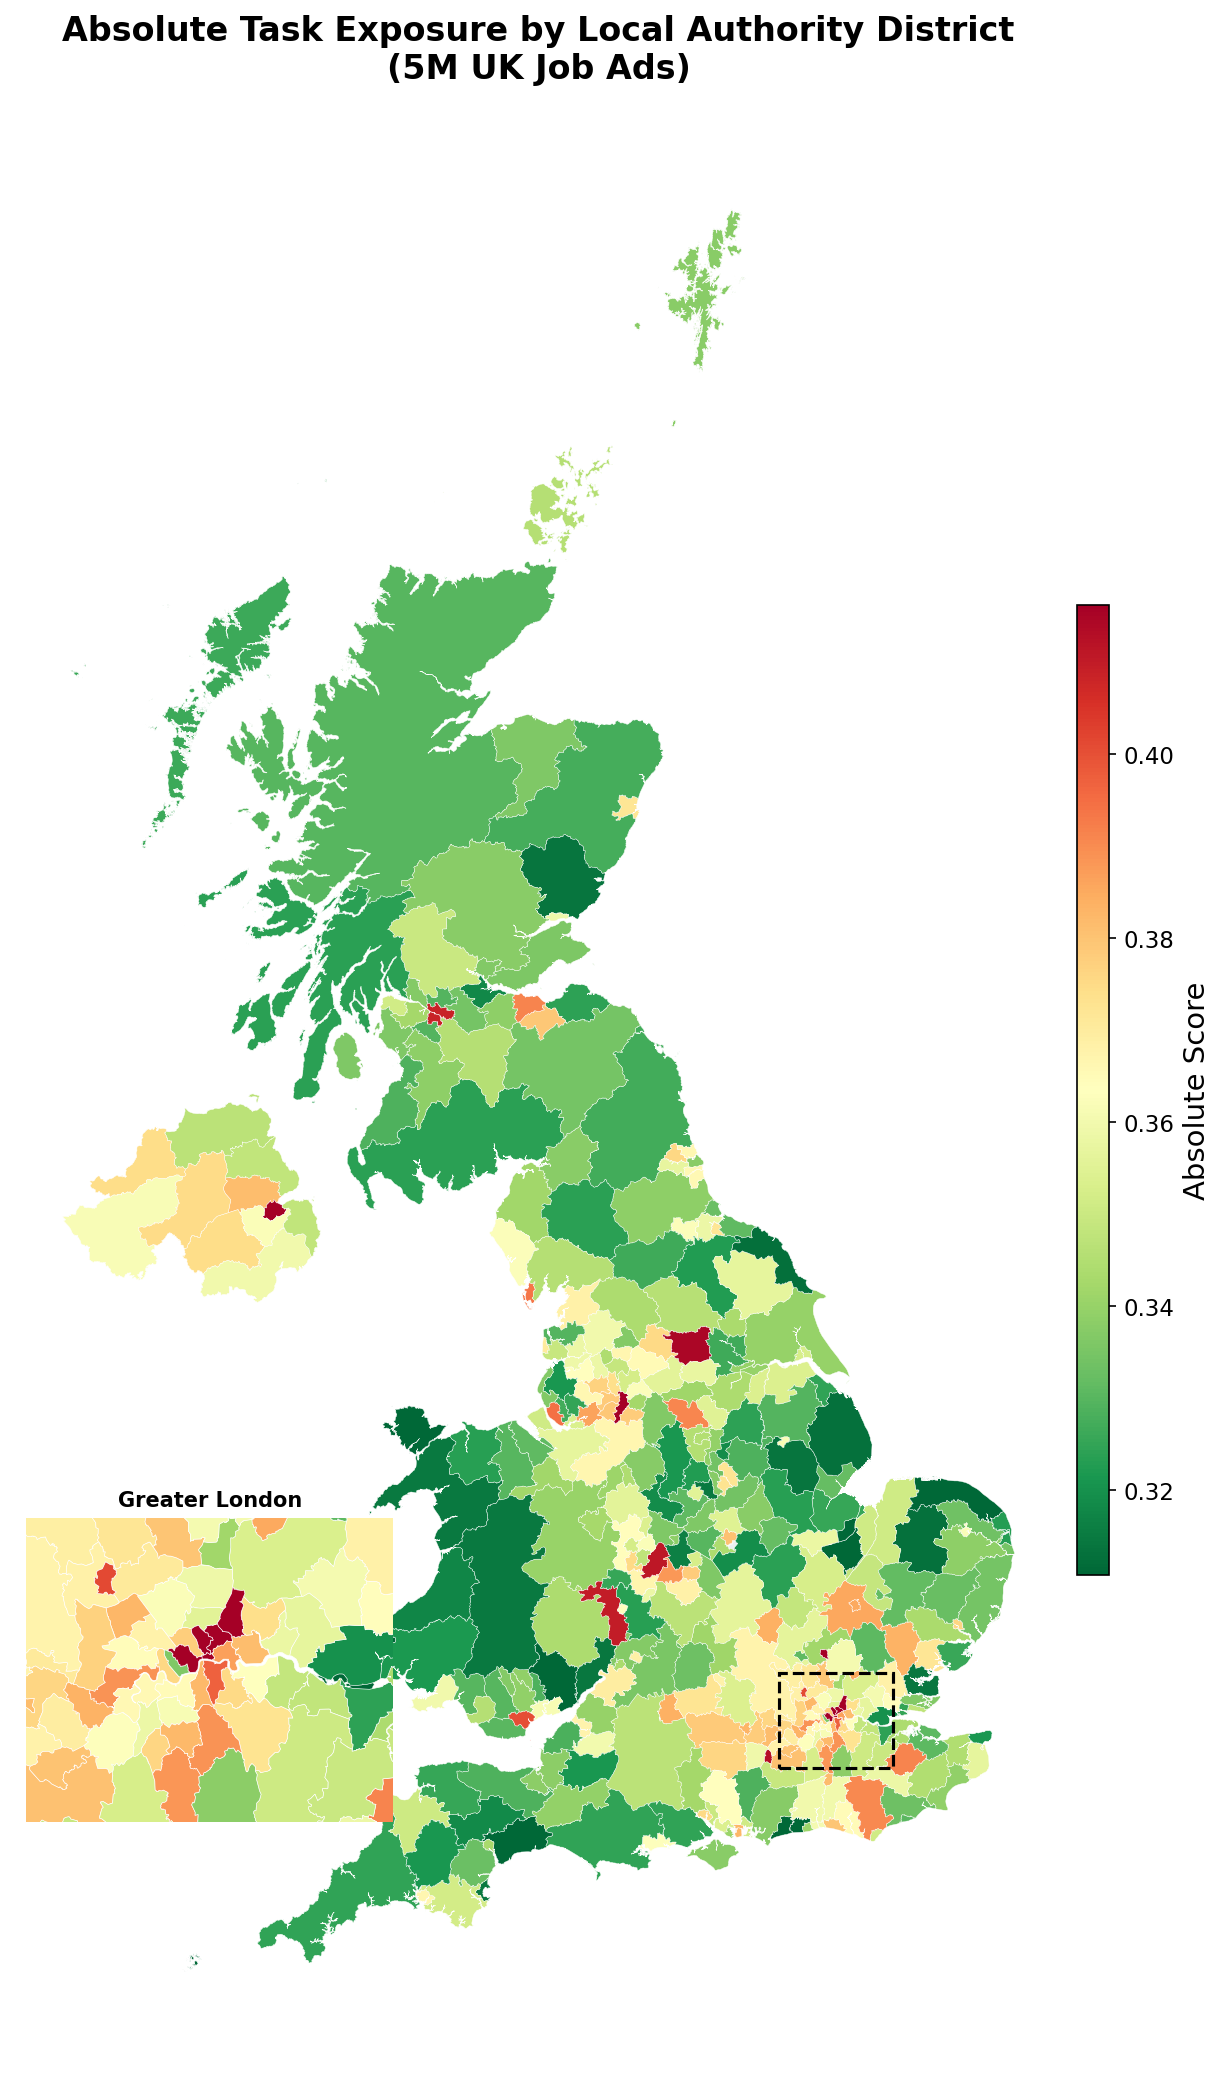

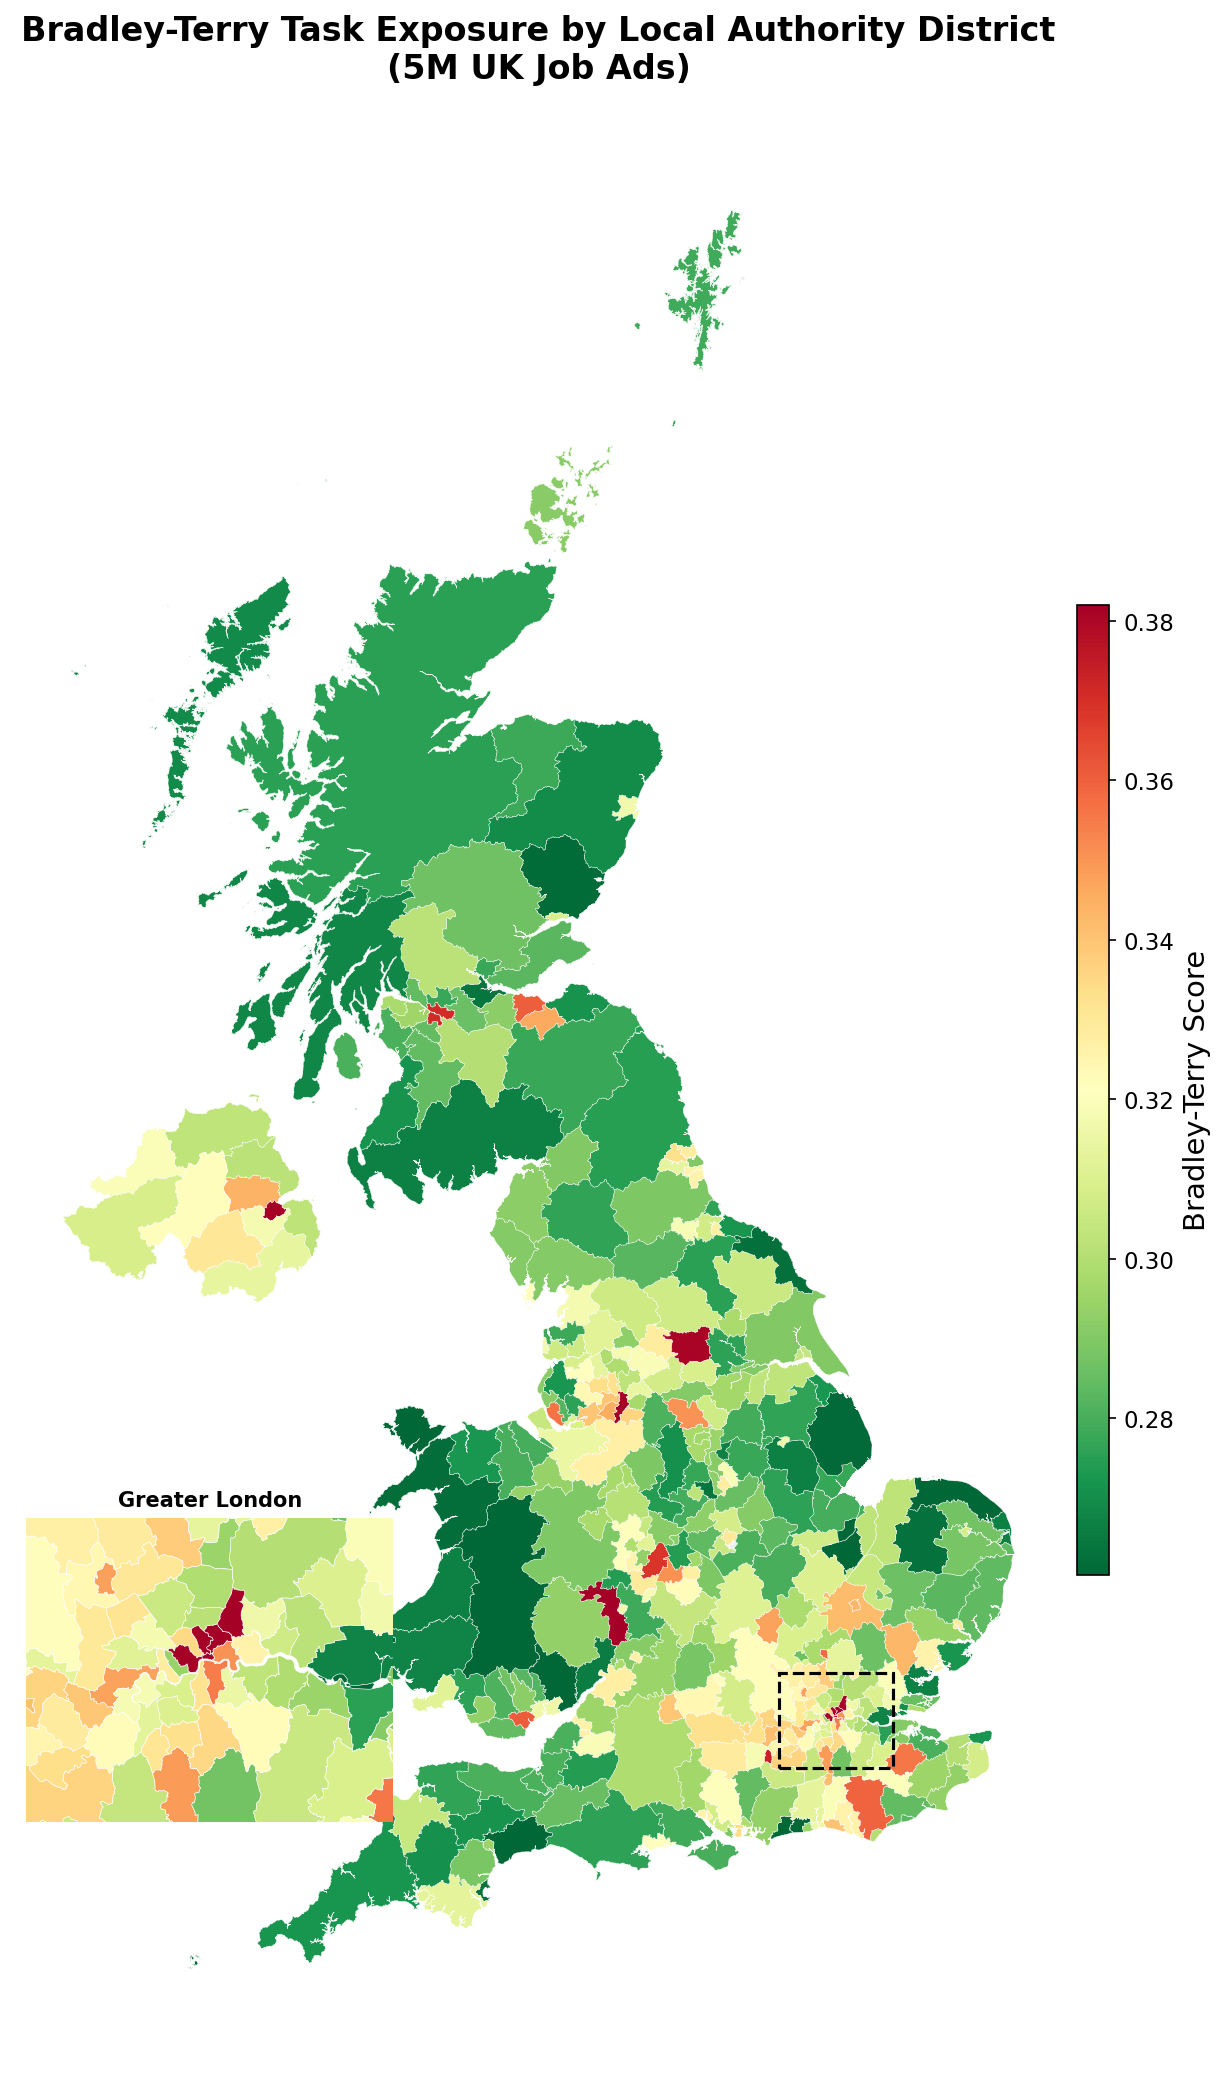

In [ ]:
# --- Side-by-side choropleth: Absolute vs BT ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = sv['col']
    unmatched = merged[merged[col].isna()]
    matched_gdf = merged[merged[col].notna()]
    vmin, vmax = matched_gdf[col].quantile(0.02), matched_gdf[col].quantile(0.98)
    
    if len(unmatched) > 0:
        unmatched.plot(ax=ax, color=GREY_LIGHT, edgecolor='white', linewidth=0.2)
    matched_gdf.plot(ax=ax, column=col, cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                     vmin=vmin, vmax=vmax, legend=True,
                     legend_kwds={'label': 'Score', 'shrink': 0.4, 'pad': 0.02})
    ax.set_axis_off()
    ax.set_title(sv['label'], fontsize=14, fontweight='bold')

fig.suptitle('AI Task Exposure by Local Authority District\n(5M UK Job Ads)',
             fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / "choropleth_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Individual choropleths with London inset ---
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    fig, ax = plt.subplots(1, 1, figsize=(10, 14))
    
    unmatched = merged[merged[col].isna()]
    if len(unmatched) > 0:
        unmatched.plot(ax=ax, color=GREY_LIGHT, edgecolor='white', linewidth=0.2)
    
    matched_gdf = merged[merged[col].notna()]
    vmin, vmax = matched_gdf[col].quantile(0.02), matched_gdf[col].quantile(0.98)
    
    matched_gdf.plot(ax=ax, column=col, cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                     vmin=vmin, vmax=vmax, legend=True,
                     legend_kwds={'label': f'{sv["label_short"]} Score', 'shrink': 0.5, 'pad': 0.01, 'aspect': 30})
    
    ax.set_axis_off()
    ax.set_title(f'{sv["label"]} by Local Authority District\n(5M UK Job Ads)',
                 fontsize=16, fontweight='bold', pad=20)
    
    # London inset
    ax_inset = inset_axes(ax, width="35%", height="35%", loc='lower left',
                           bbox_to_anchor=(0.0, 0.02, 1, 1), bbox_transform=ax.transAxes)
    london = merged[merged['LAD22CD'].str.startswith('E09')]
    lb = london.total_bounds; pad = 10000
    ax_inset.set_xlim(lb[0]-pad, lb[2]+pad)
    ax_inset.set_ylim(lb[1]-pad, lb[3]+pad)
    merged.plot(ax=ax_inset, column=col, cmap='RdYlGn_r', edgecolor='white', linewidth=0.3,
                vmin=vmin, vmax=vmax, missing_kwds={'color': GREY_LIGHT})
    ax_inset.set_axis_off()
    ax_inset.set_title('Greater London', fontsize=10, fontweight='bold')
    
    rect = Rectangle((lb[0]-pad, lb[1]-pad), lb[2]-lb[0]+2*pad, lb[3]-lb[1]+2*pad,
                      linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"choropleth_{key}.png", dpi=300, bbox_inches='tight')
    plt.show()

**Observations:**
- **London** (inset) is the clear hotspot for AI task exposure. The City of London and Westminster (deep red) host the highest concentrations of AI-exposed white-collar jobs (finance, legal, consulting).
- Other **urban centers** (Manchester, Birmingham, Edinburgh, Leeds) show moderate-to-high exposure, visible as orange/yellow clusters.
- **Rural areas and the Scottish Highlands** are consistently green (low exposure), reflecting economies dominated by agriculture, tourism, and manual trades.
- The pattern maps closely to the UK's knowledge-economy geography: areas with more professional/office-based employment have higher AI task exposure.

In [ ]:
# Top and bottom 10 LADs by task exposure (both variants)
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    geo_sorted = geo_df.sort_values(col, ascending=False)
    
    print(f"### {sv['label']}: Top 10 LADs")
    top10 = geo_sorted.head(10)[['LAD22NM', col, 'presence_composite', 'n_ads']]
    print(top10.to_markdown(index=False, floatfmt='.4f'))
    
    print(f"\n### {sv['label']}: Bottom 10 LADs")
    bottom10 = geo_sorted.tail(10)[['LAD22NM', col, 'presence_composite', 'n_ads']]
    print(bottom10.to_markdown(index=False, floatfmt='.4f'))
    print()

### Absolute Task Exposure: Top 10 LADs
| LAD22NM        |   task_exposure_mean |   presence_composite |   n_ads |
|:---------------|---------------------:|---------------------:|--------:|
| City of London |               0.4643 |               0.5257 |   66194 |
| Waltham Forest |               0.4345 |               0.5287 |   12695 |
| Islington      |               0.4332 |               0.5343 |   22386 |
| Hackney        |               0.4313 |               0.5285 |   12941 |
| Manchester     |               0.4300 |               0.5248 |  120101 |
| Belfast        |               0.4252 |               0.5181 |   24667 |
| Stevenage      |               0.4197 |               0.5305 |    3019 |
| Westminster    |               0.4173 |               0.5208 |   77318 |
| Leeds          |               0.4149 |               0.5229 |   64123 |
| Rushmoor       |               0.4126 |               0.5220 |    5026 |

### Absolute Task Exposure: Bottom 10 LADs
| LAD22NM       

| Region     |   n_lads |   n_ads |   felten_score_wmean |   task_exposure_mean_wmean |   task_exposure_bt_mean_wmean |   presence_composite_wmean |
|:-----------|---------:|--------:|---------------------:|---------------------------:|------------------------------:|---------------------------:|
| London     |       33 |  412312 |               0.5968 |                     0.4029 |                        0.3656 |                     0.5252 |
| Rest of UK |      340 | 2892305 |               0.5875 |                     0.3632 |                        0.3187 |                     0.5194 |


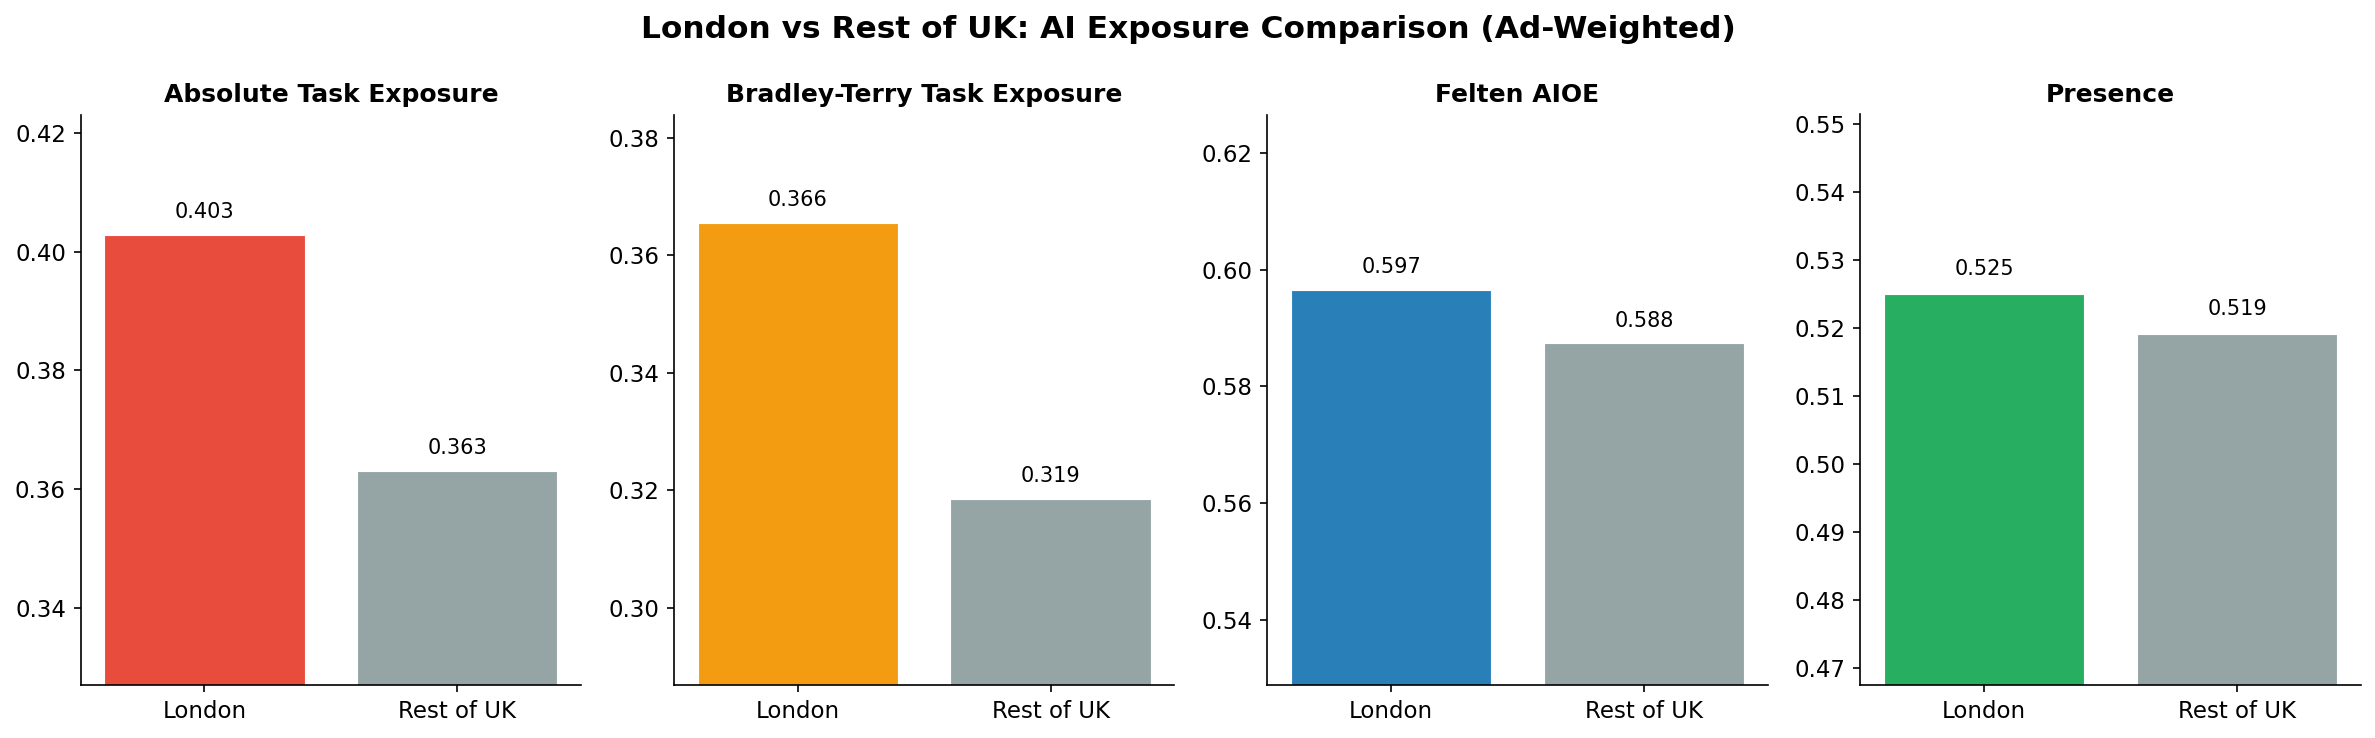

In [ ]:
# London vs Rest of UK
geo_df['is_london'] = geo_df['LAD22CD'].str.startswith('E09')

score_cols_geo = ['felten_score', 'task_exposure_mean', 'task_exposure_bt_mean',
                  'presence_composite', 'presence_physical', 'presence_emotional', 'presence_creative']

london_rest = geo_df.groupby('is_london').agg(
    n_lads=('LAD22CD', 'count'),
    n_ads=('n_ads', 'sum'),
    **{f'{c}_wmean': (c, lambda x, col=c: np.average(x, weights=geo_df.loc[x.index, 'n_ads']))
       for c in score_cols_geo}
).reset_index()
london_rest['Region'] = london_rest['is_london'].map({True: 'London', False: 'Rest of UK'})

# Sort so London comes first
london_rest = london_rest.sort_values('is_london', ascending=False).reset_index(drop=True)

display_cols = ['Region', 'n_lads', 'n_ads'] + [f'{c}_wmean' for c in score_cols_geo[:4]]
print(london_rest[display_cols].to_markdown(index=False, floatfmt='.4f'))

# Bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
compare_cols = [('task_exposure_mean_wmean', 'Absolute Task Exposure', ACCENT),
                ('task_exposure_bt_mean_wmean', 'Bradley-Terry Task Exposure', ORANGE),
                ('felten_score_wmean', 'Felten AIOE', SECONDARY),
                ('presence_composite_wmean', 'Presence', GREEN)]

for ax, (col, label, color) in zip(axes, compare_cols):
    vals = london_rest[col].values
    bars = ax.bar(['London', 'Rest of UK'], vals, color=[color, GREY_MED],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(min(vals) * 0.9, max(vals) * 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}',
                ha='center', va='bottom', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('London vs Rest of UK: AI Exposure Comparison (Ad-Weighted)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / "london_vs_rest.png", dpi=300, bbox_inches='tight')
plt.show()

**Observations:**
- London has **11% higher task exposure** (0.403 vs 0.363) and **15% higher BT exposure** (0.366 vs 0.319) than the rest of the UK, reflecting its concentration of professional services, finance, and tech jobs.
- **Felten and Presence** differences are much smaller (1.5% and 1.2% respectively), consistent with these metrics having narrow spreads across all geographies.
- London accounts for 412K of 3.3M geo-located ads (12.5% of the sample), spread across 33 boroughs.

## 7. Task Exposure vs Human Presence: Quadrant Analysis

This scatter reveals which occupations are most vulnerable (high AI exposure, low human presence) vs resilient (low exposure, high presence).

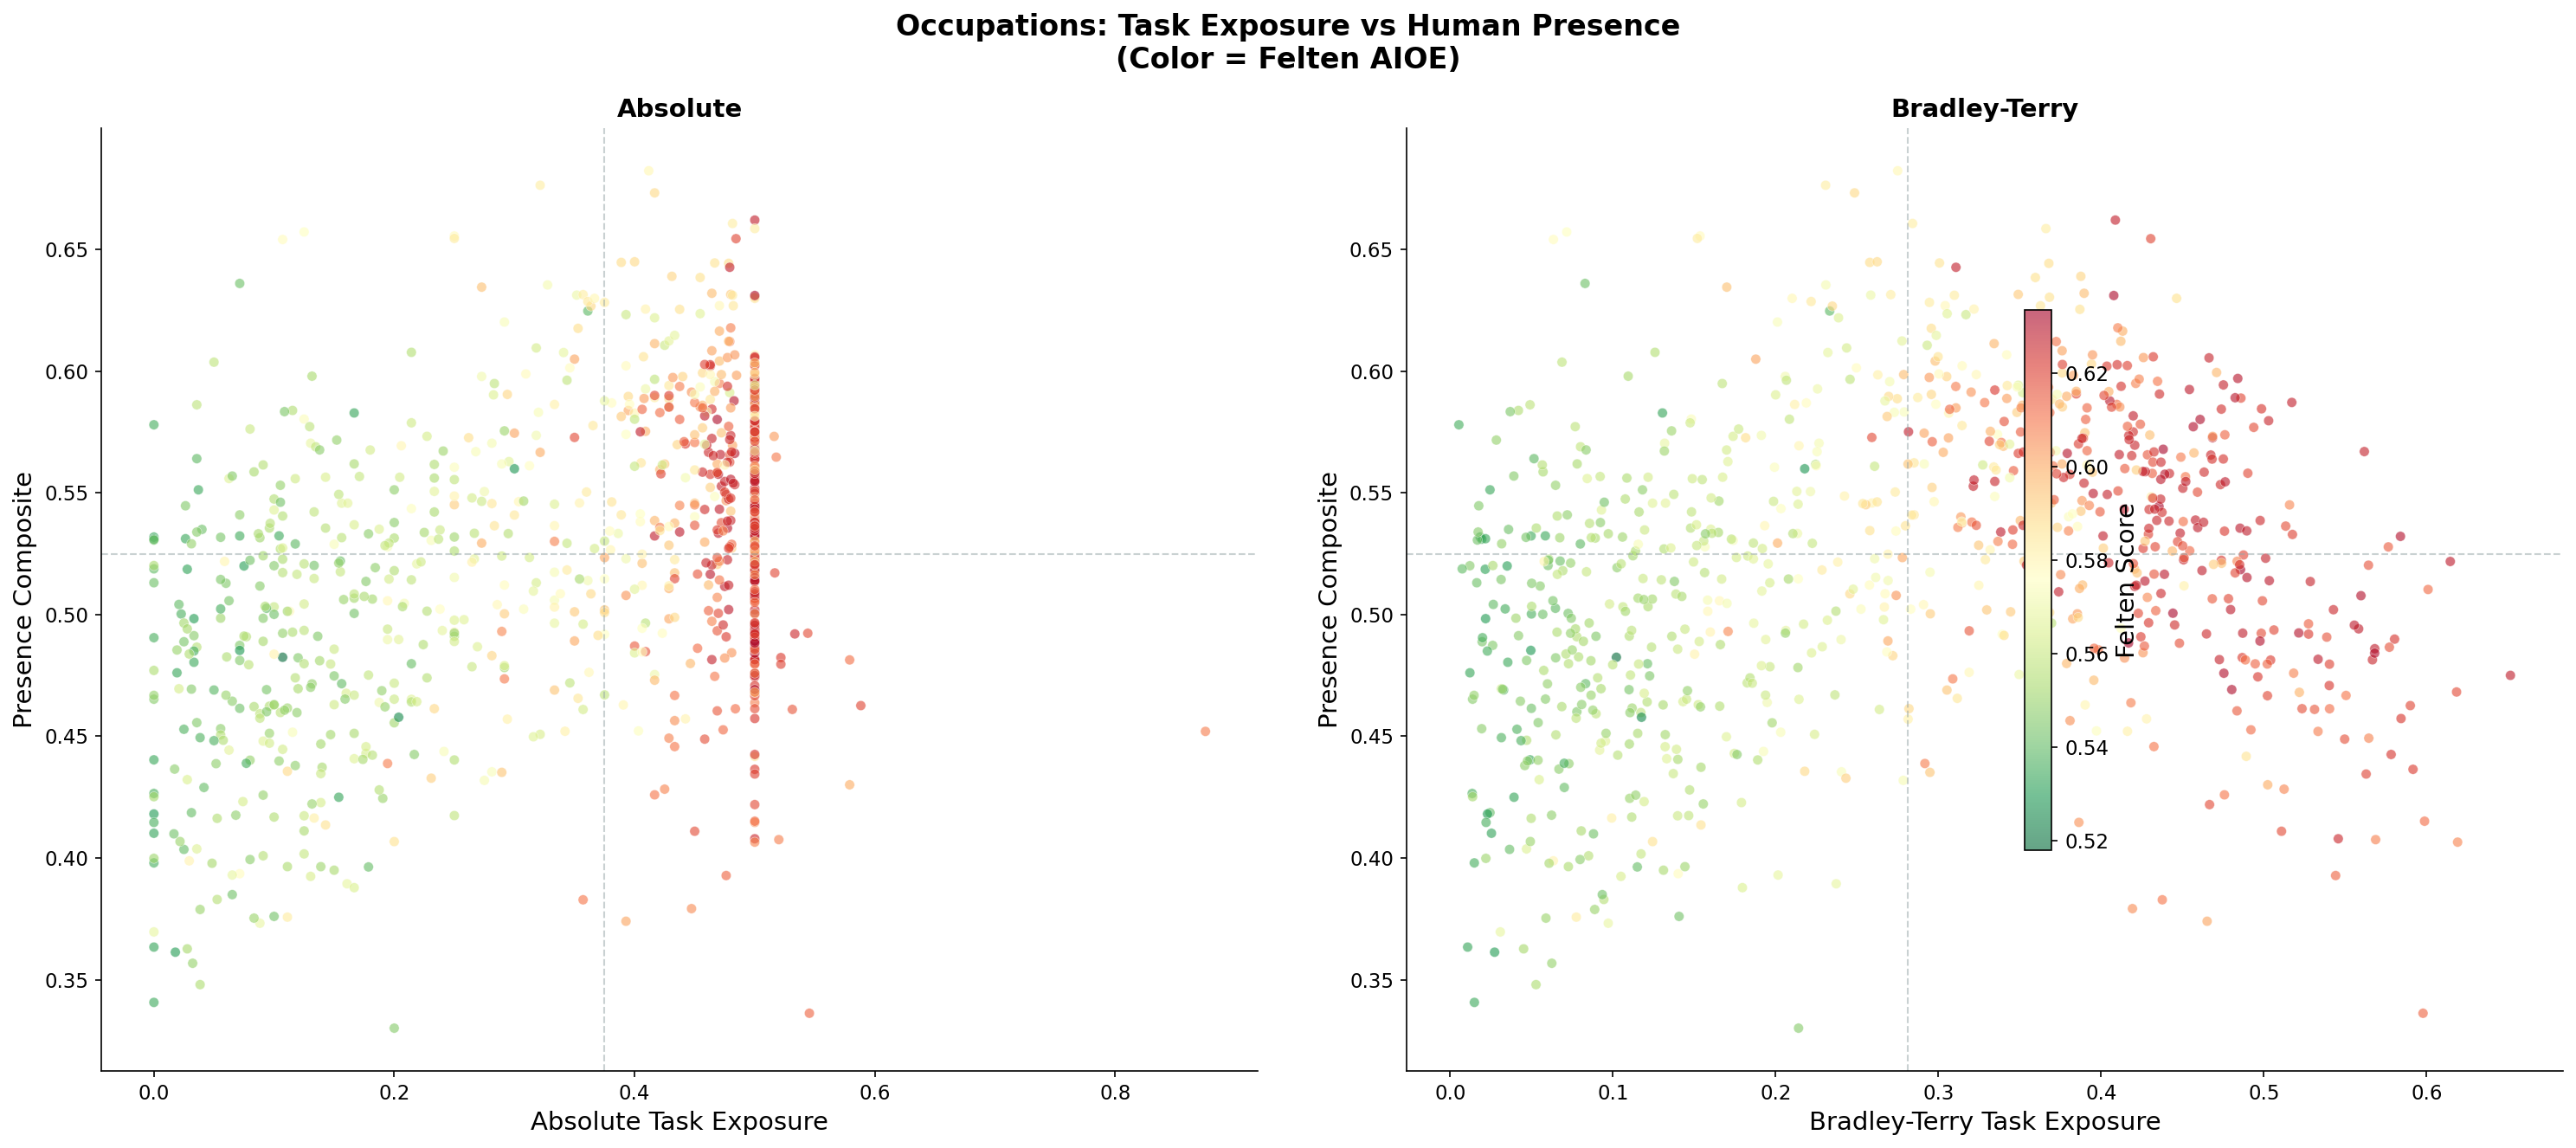

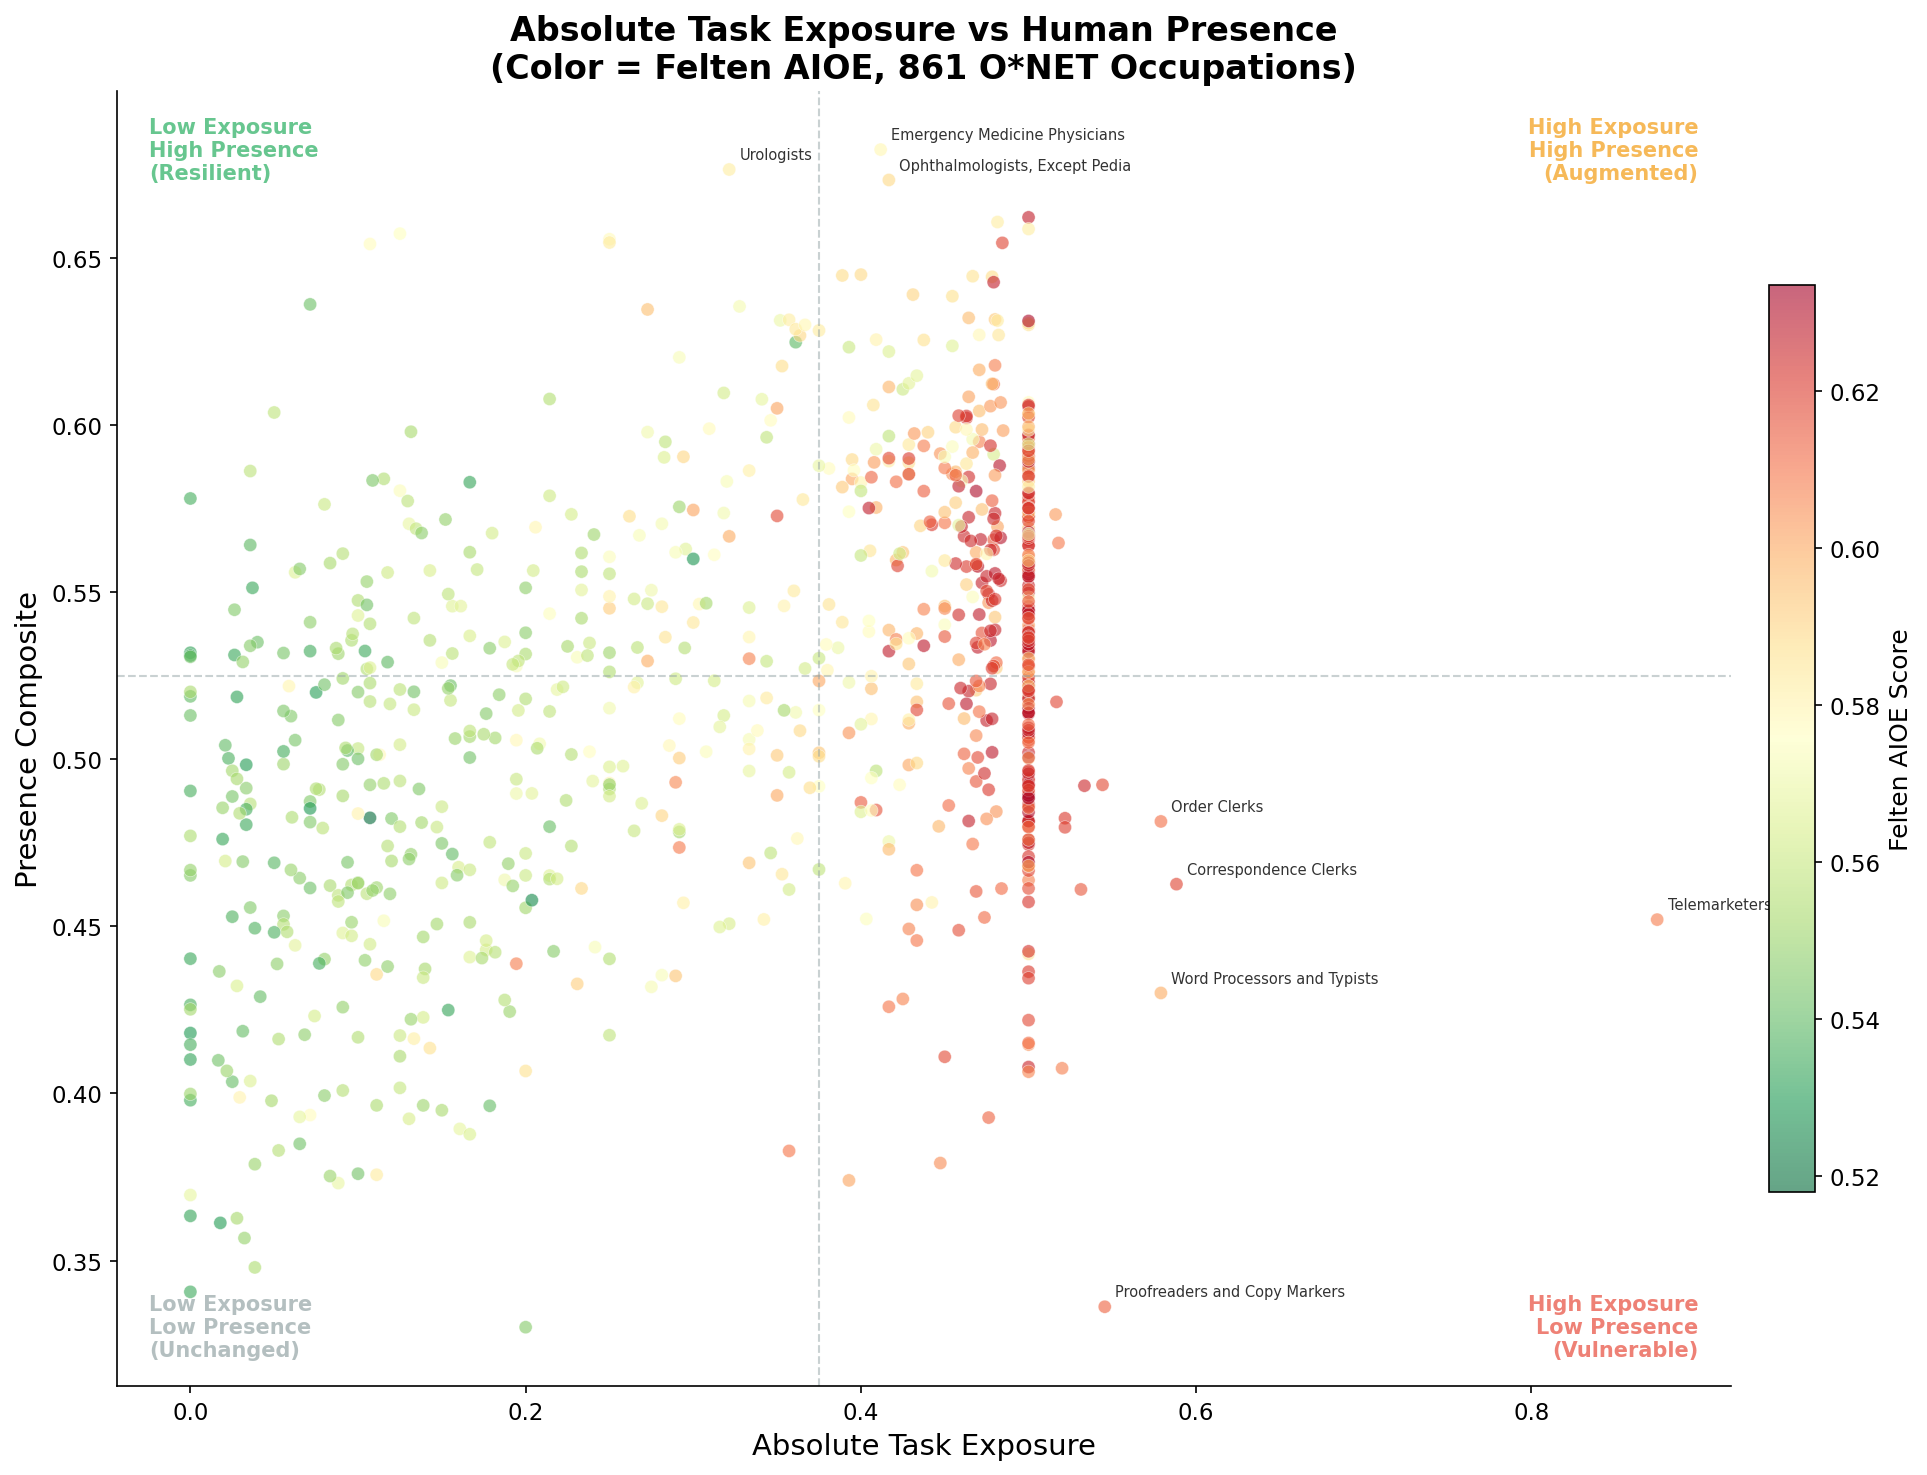

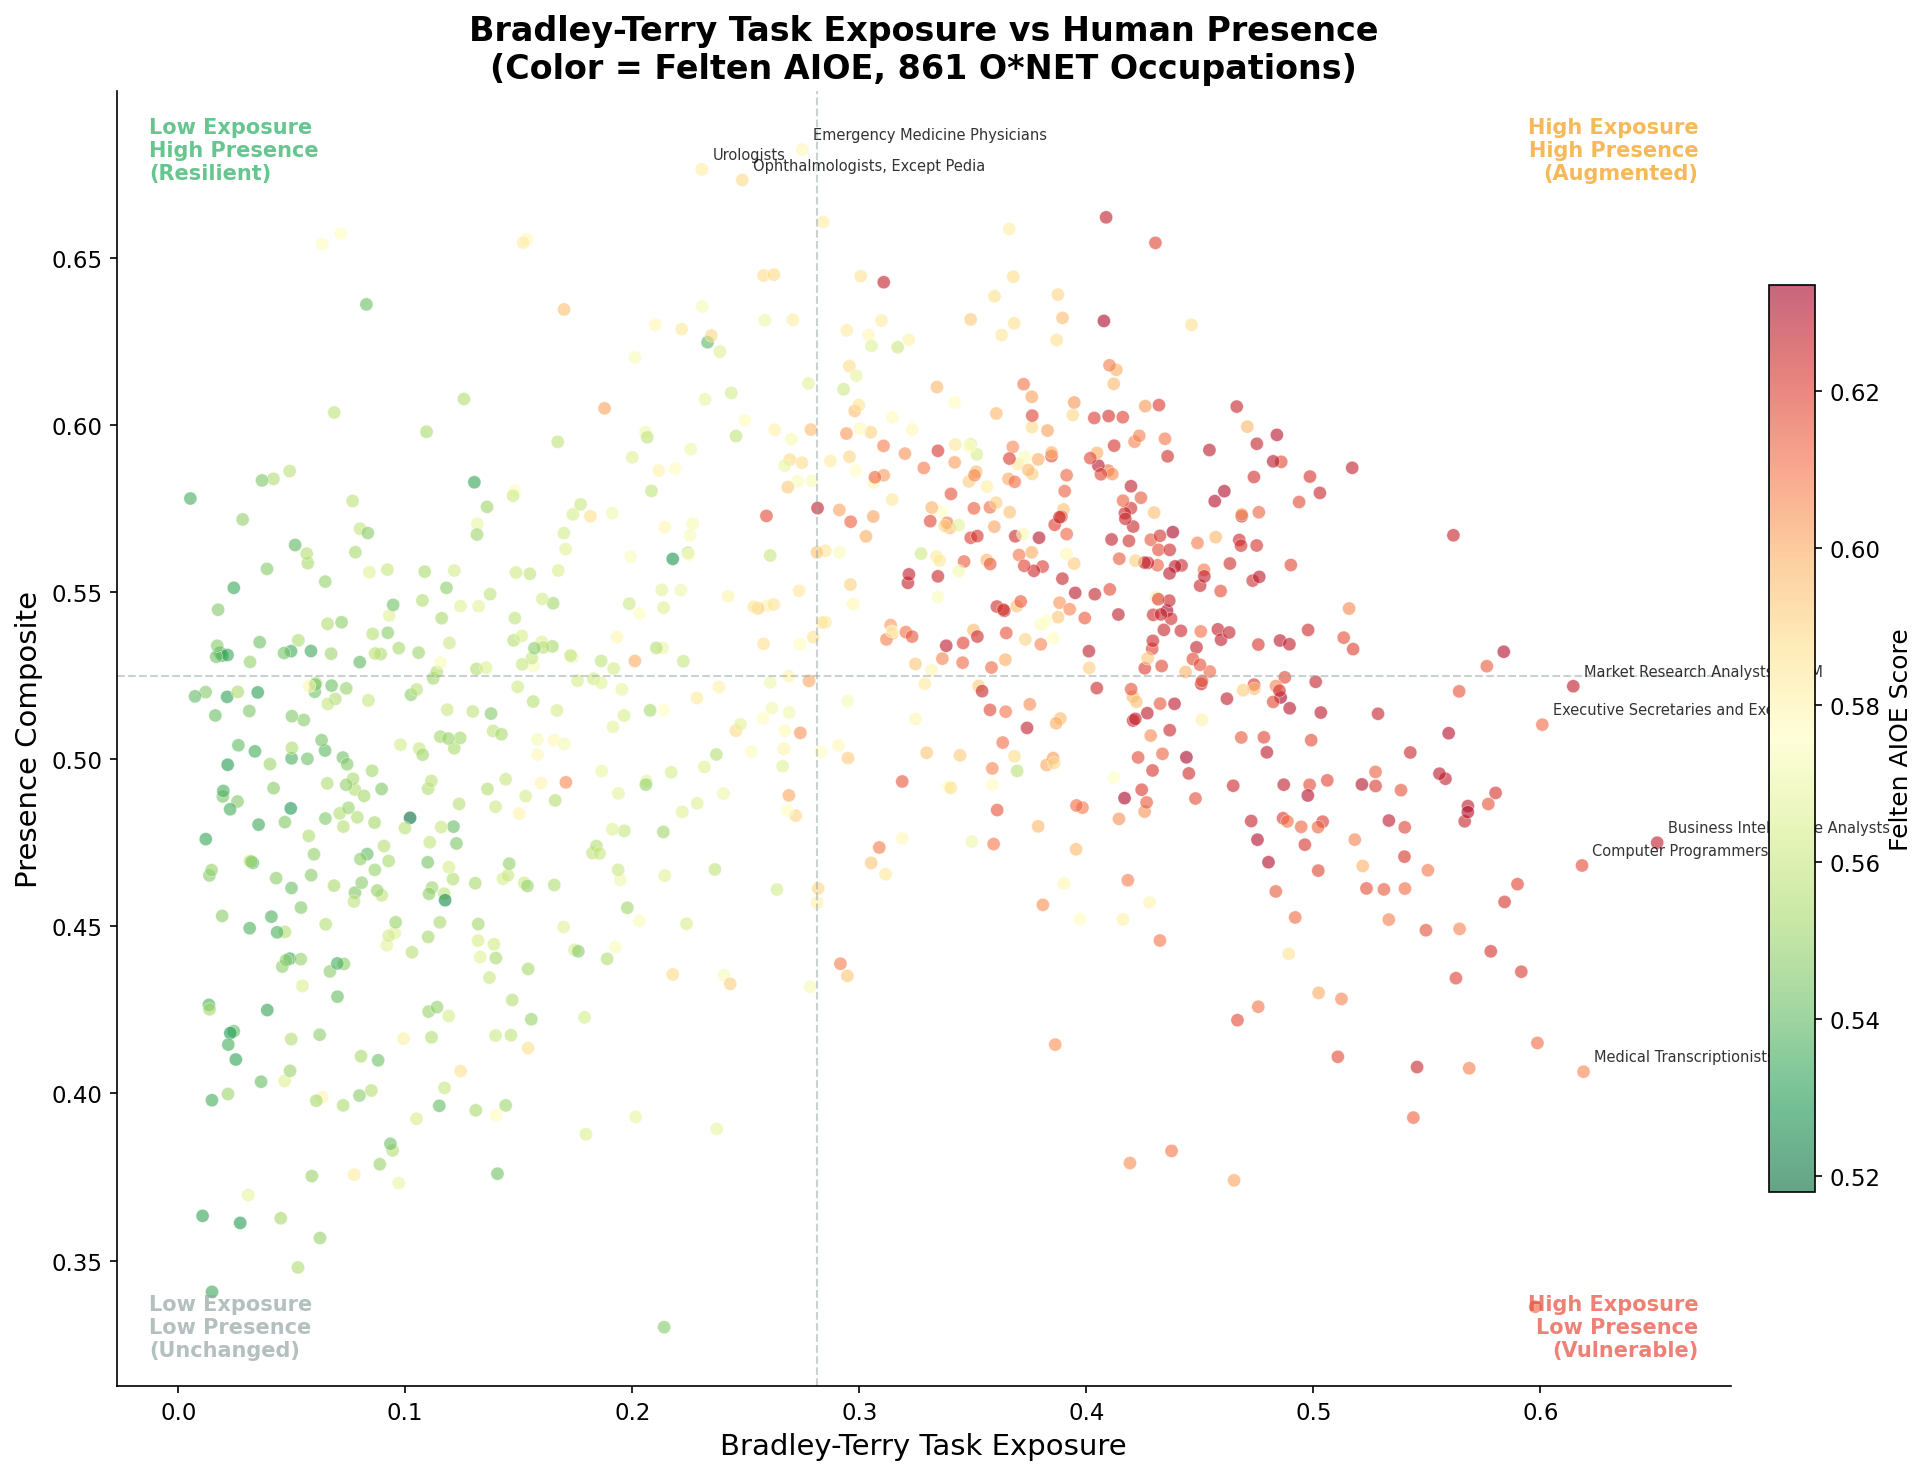

In [ ]:
# --- Side-by-side quadrant scatter: Absolute vs BT ---
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, (key, sv) in zip(axes, SCORE_VARIANTS.items()):
    col = sv['col']
    scatter = ax.scatter(onet_df[col], onet_df['presence_composite'],
        c=onet_df['felten_score'], cmap='RdYlGn_r', s=30, alpha=0.6, edgecolor='white', linewidth=0.3)
    
    med_x = onet_df[col].median()
    med_y = onet_df['presence_composite'].median()
    ax.axvline(med_x, color=GREY_MED, linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(med_y, color=GREY_MED, linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel(sv['label'])
    ax.set_ylabel('Presence Composite')
    ax.set_title(sv['label_short'], fontsize=14, fontweight='bold')

fig.suptitle('Occupations: Task Exposure vs Human Presence\n(Color = Felten AIOE)',
             fontsize=16, fontweight='bold')
plt.colorbar(scatter, ax=axes, shrink=0.6, label='Felten Score')
plt.tight_layout()
plt.savefig(OUT_DIR / "quadrant_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Individual quadrant plots ---
for key, sv in SCORE_VARIANTS.items():
    col = sv['col']
    fig, ax = plt.subplots(figsize=(14, 10))
    
    scatter = ax.scatter(onet_df[col], onet_df['presence_composite'],
        c=onet_df['felten_score'], cmap='RdYlGn_r', s=40, alpha=0.6, edgecolor='white', linewidth=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Felten AIOE Score', fontsize=12)
    
    med_x = onet_df[col].median()
    med_y = onet_df['presence_composite'].median()
    ax.axvline(med_x, color=GREY_MED, linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(med_y, color=GREY_MED, linestyle='--', linewidth=1, alpha=0.5)
    
    ax.text(0.02, 0.98, 'Low Exposure\nHigh Presence\n(Resilient)', transform=ax.transAxes,
            fontsize=10, va='top', ha='left', color=GREEN, fontweight='bold', alpha=0.7)
    ax.text(0.98, 0.98, 'High Exposure\nHigh Presence\n(Augmented)', transform=ax.transAxes,
            fontsize=10, va='top', ha='right', color=ORANGE, fontweight='bold', alpha=0.7)
    ax.text(0.02, 0.02, 'Low Exposure\nLow Presence\n(Unchanged)', transform=ax.transAxes,
            fontsize=10, va='bottom', ha='left', color=GREY_MED, fontweight='bold', alpha=0.7)
    ax.text(0.98, 0.02, 'High Exposure\nLow Presence\n(Vulnerable)', transform=ax.transAxes,
            fontsize=10, va='bottom', ha='right', color=ACCENT, fontweight='bold', alpha=0.7)
    
    for _, row in onet_df.nlargest(5, col).iterrows():
        ax.annotate(row['title'][:30], (row[col], row['presence_composite']),
                    fontsize=7, alpha=0.8, textcoords='offset points', xytext=(5, 5))
    for _, row in onet_df.nlargest(3, 'presence_composite').iterrows():
        ax.annotate(row['title'][:30], (row[col], row['presence_composite']),
                    fontsize=7, alpha=0.8, textcoords='offset points', xytext=(5, 5))
    
    ax.set_xlabel(sv['label'], fontsize=14)
    ax.set_ylabel('Presence Composite', fontsize=14)
    ax.set_title(f'{sv["label"]} vs Human Presence\n(Color = Felten AIOE, 861 O*NET Occupations)',
                 fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"quadrant_task_vs_presence_{key}.png", dpi=300, bbox_inches='tight')
    plt.show()

**Observations:**
- There is a clear **negative correlation** between task exposure and presence: occupations with high physical/emotional/creative presence requirements tend to have low AI task exposure, and vice versa. This is intuitive -- tasks requiring human presence are harder to automate.
- The **"Vulnerable" quadrant** (high exposure, low presence) contains Telemarketers, Proofreaders, Word Processors, Correspondence Clerks. These have highly automatable tasks *and* little need for human presence.
- The **"Resilient" quadrant** (low exposure, high presence) contains physicians, surgeons, and other healthcare roles requiring physical touch, emotional engagement, and clinical judgment.
- The **"Augmented" quadrant** (high exposure, high presence) is relatively sparse, suggesting few occupations combine high AI exposure with strong human presence requirements. Those that do (e.g. some management/counseling roles) represent jobs where AI may augment rather than replace.
- Felten color (ability-based) does not strongly track either axis, confirming it captures a different, less discriminating dimension of AI exposure.

## 8. Human Presence Breakdown: Physical, Emotional, Creative

The presence composite score aggregates three dimensions of human presence. Different occupational families rely on different types of presence, revealing distinct patterns of AI resilience.

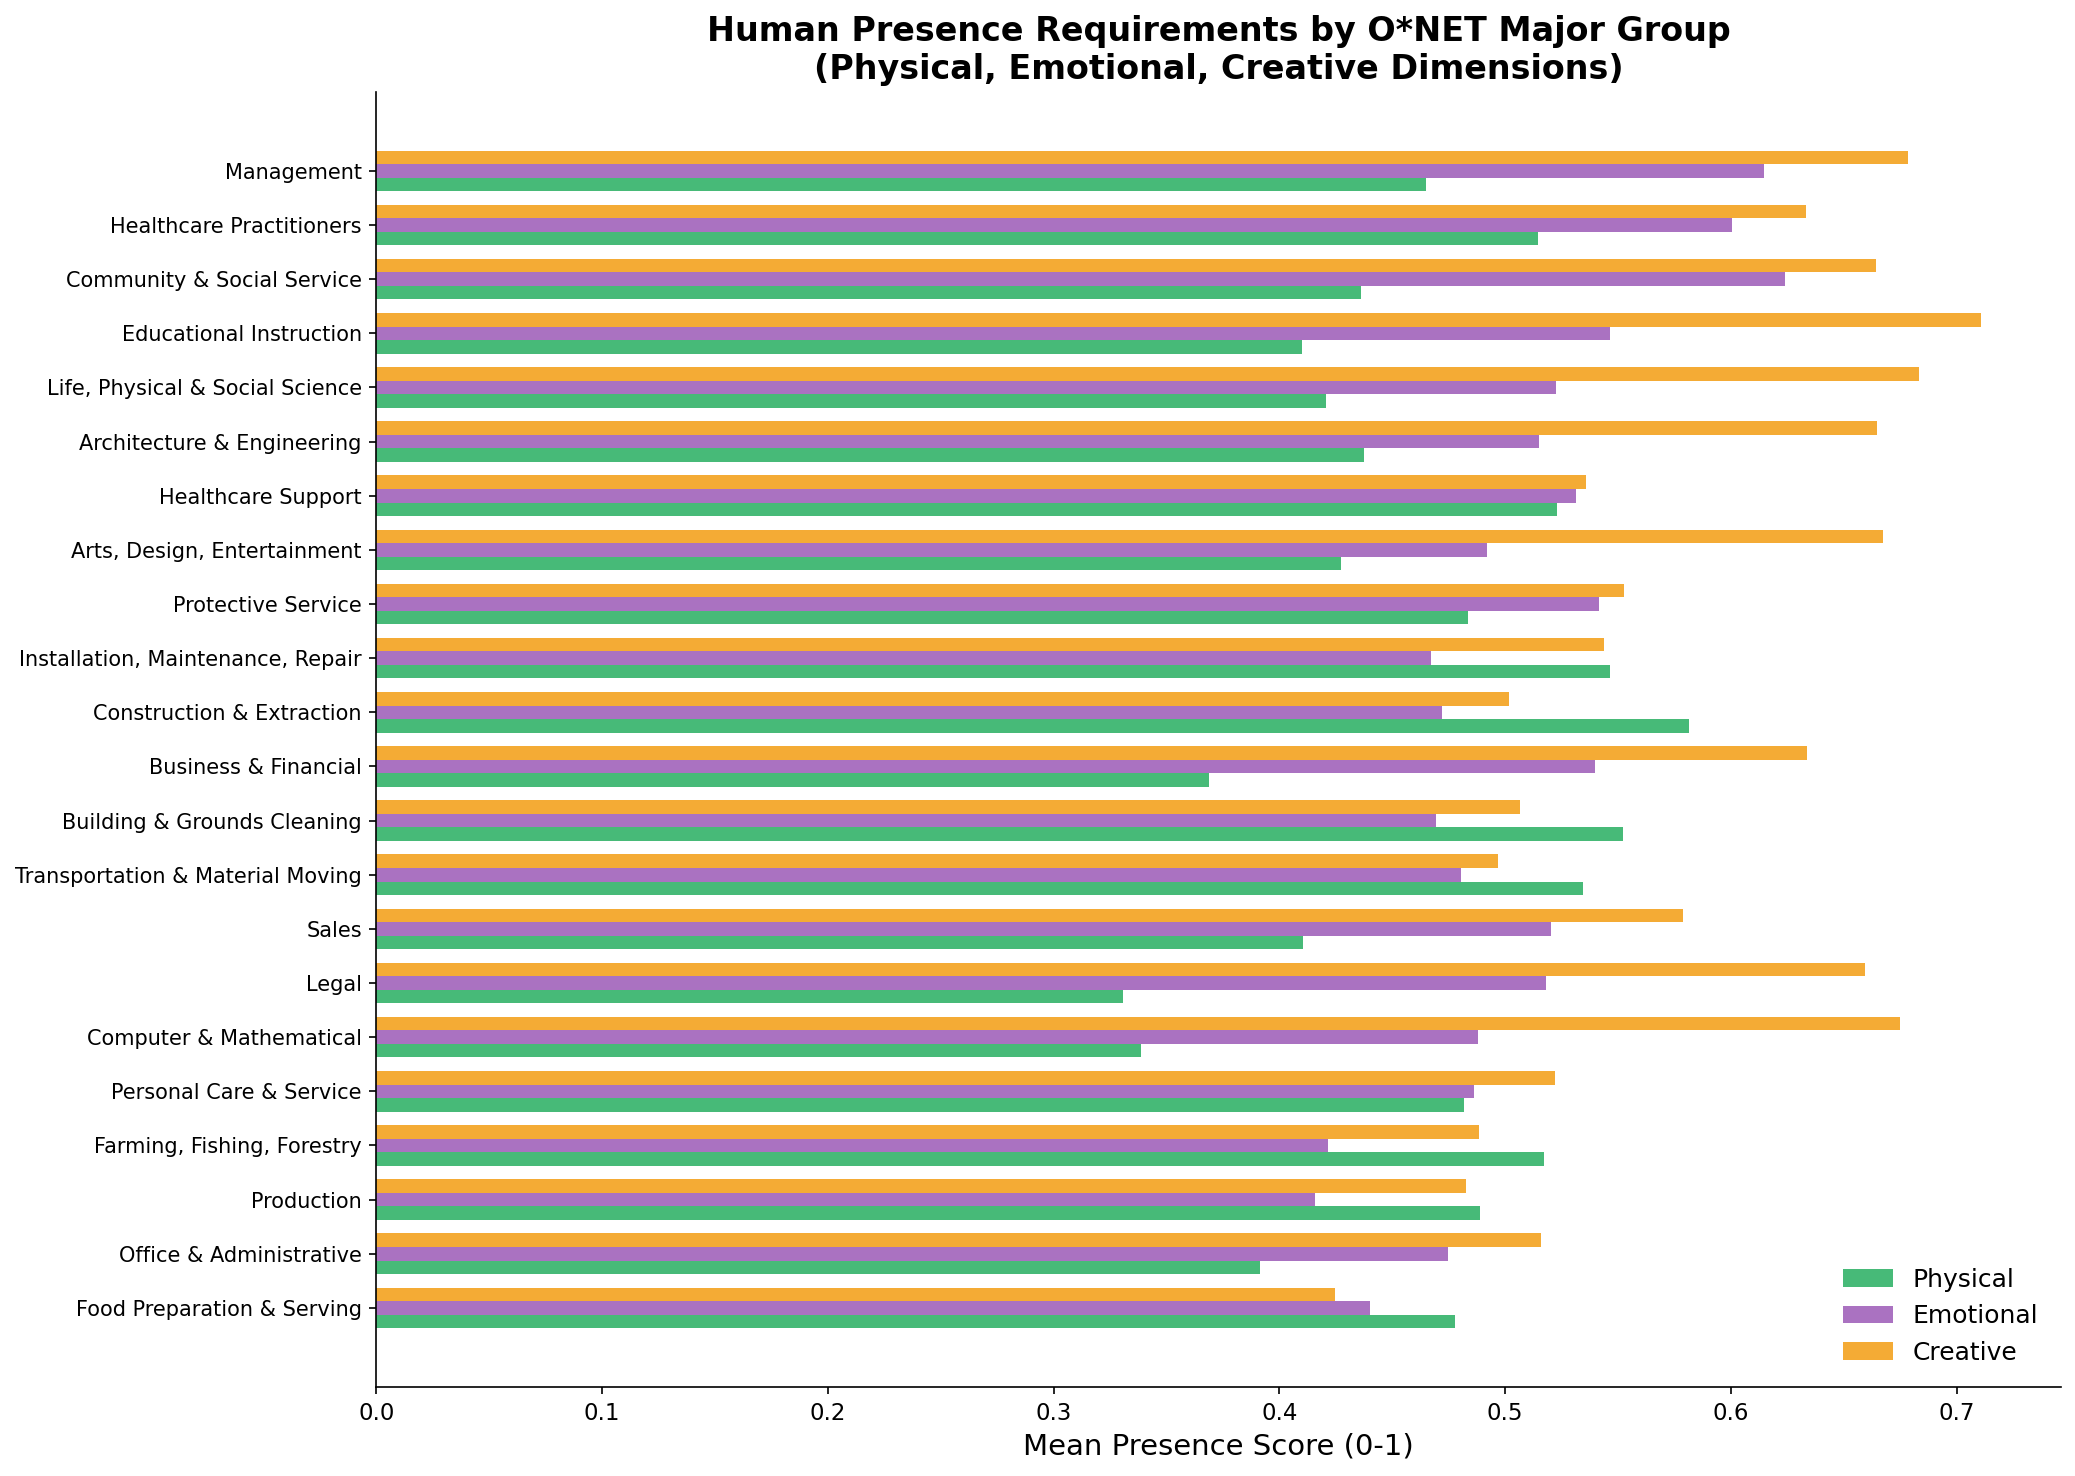

In [ ]:
# Presence breakdown by O*NET major group
presence_by_group = onet_df.groupby('major_group').agg(
    physical=('presence_physical', 'mean'),
    emotional=('presence_emotional', 'mean'),
    creative=('presence_creative', 'mean'),
    composite=('presence_composite', 'mean'),
).reset_index().sort_values('composite', ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
y_pos = np.arange(len(presence_by_group))

# Grouped bars for each presence type
bar_h = 0.25
ax.barh(y_pos - bar_h, presence_by_group['physical'], bar_h,
        color=GREEN, alpha=0.85, label='Physical')
ax.barh(y_pos, presence_by_group['emotional'], bar_h,
        color=PURPLE, alpha=0.85, label='Emotional')
ax.barh(y_pos + bar_h, presence_by_group['creative'], bar_h,
        color=ORANGE, alpha=0.85, label='Creative')

ax.set_yticks(y_pos)
ax.set_yticklabels(presence_by_group['major_group'], fontsize=10)
ax.set_xlabel('Mean Presence Score (0-1)', fontsize=14)
ax.set_title('Human Presence Requirements by O*NET Major Group\n(Physical, Emotional, Creative Dimensions)',
             fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig(OUT_DIR / "presence_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()

**Observations:**
- **Creative presence** (orange) is consistently the dominant dimension across most groups, especially Management, Healthcare Practitioners, and Community & Social Service. Judgment and creative problem-solving are the hardest capabilities to automate.
- **Physical presence** (green) dominates in manual trades: Construction & Extraction, Building & Grounds Cleaning, Installation/Maintenance/Repair, and Farming. These groups derive their AI resilience primarily from physical requirements.
- **Emotional presence** (purple) is highest in caring professions: Healthcare Practitioners, Community & Social Service, Educational Instruction. Human connection and empathy are central to these roles.
- Each major group has a distinctive presence *profile*: Construction is physical-dominant, Healthcare is emotional-dominant, Management is creative-dominant. This suggests different groups will face AI disruption along different dimensions.
- **Food Preparation & Serving** has the lowest composite score despite moderate physical presence, reflecting relatively low emotional and creative requirements compared to other groups.

## 9. Score Correlation Matrix

How do the different exposure and presence metrics relate to each other?

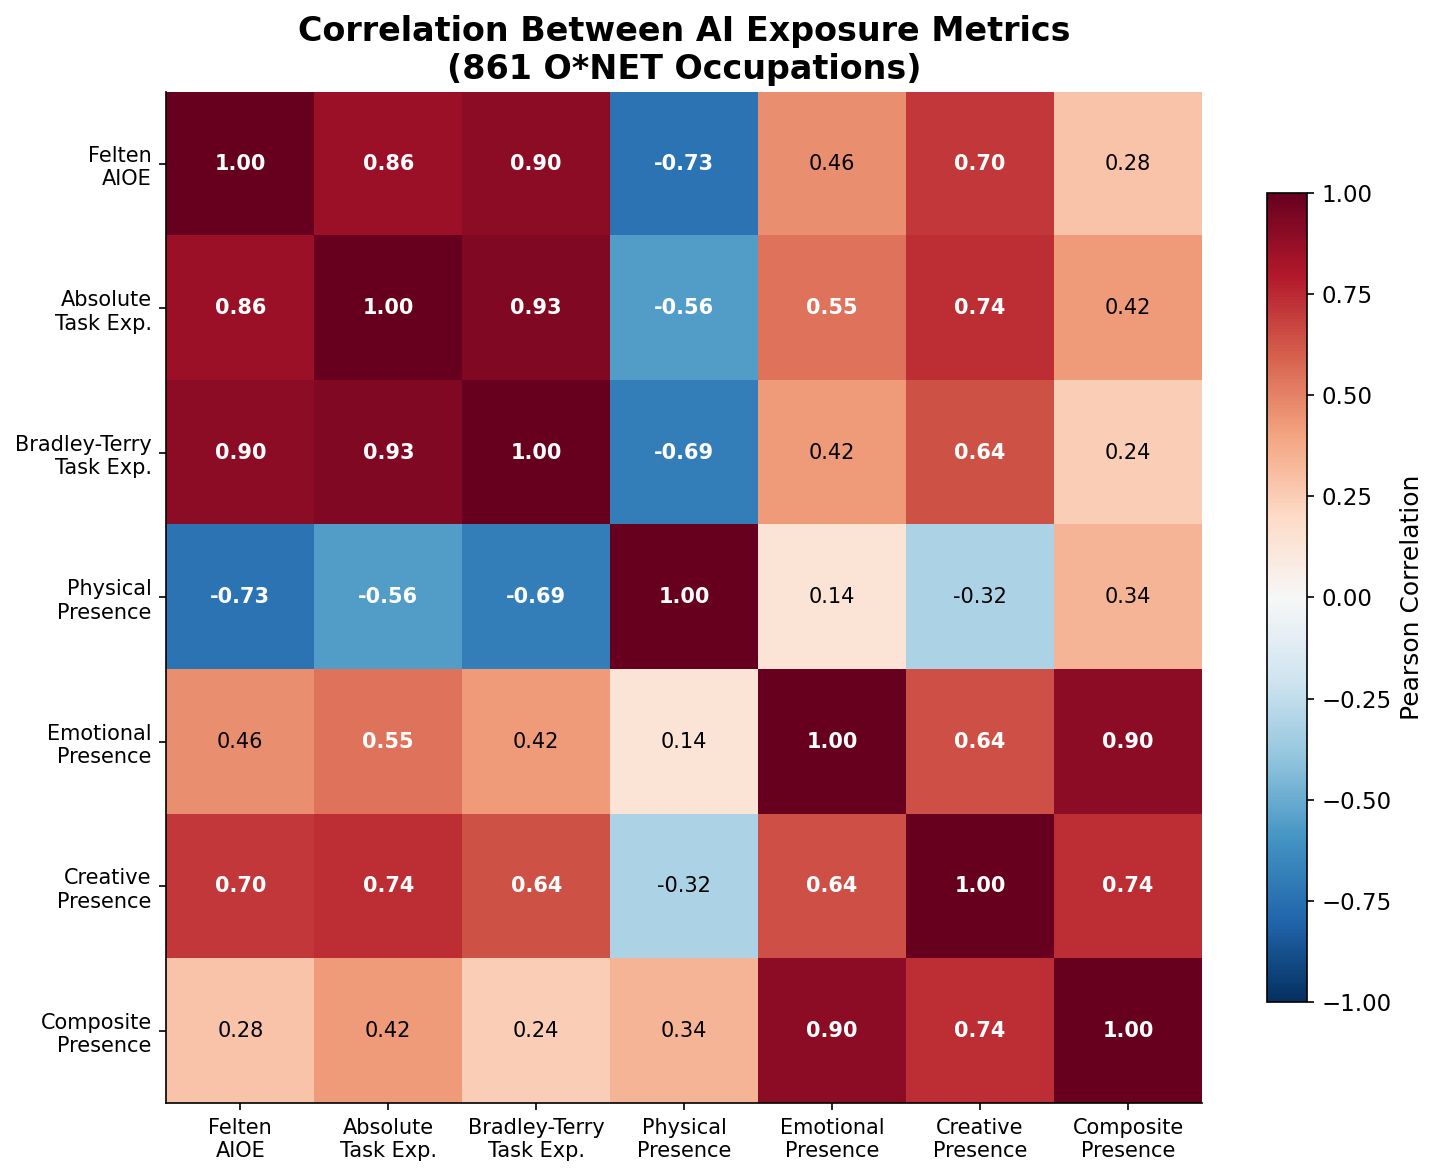

In [ ]:
# Correlation matrix of all score dimensions
corr_cols = ['felten_score', 'task_exposure_mean', 'task_exposure_bt_mean',
             'presence_physical', 'presence_emotional', 'presence_creative', 'presence_composite']
corr_labels = ['Felten\nAIOE', 'Absolute\nTask Exp.', 'Bradley-Terry\nTask Exp.',
               'Physical\nPresence', 'Emotional\nPresence', 'Creative\nPresence', 'Composite\nPresence']

corr_matrix = onet_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, fontsize=10)
ax.set_yticklabels(corr_labels, fontsize=10)

# Annotate cells
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10,
                color=color, fontweight='bold' if abs(val) > 0.5 else 'normal')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Pearson Correlation', fontsize=12)

ax.set_title('Correlation Between AI Exposure Metrics\n(861 O*NET Occupations)',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / "correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

**Observations:**
- The **three exposure metrics** (Felten, Task Exposure, BT) are highly correlated (r=0.86--0.93), suggesting convergent validity despite different methodologies (ability-based vs task-based vs pairwise ranking).
- **Physical presence is strongly negatively correlated** with all exposure metrics (r=-0.56 to -0.73). This is the clearest pattern: hands-on physical work provides the strongest protection against AI task exposure.
- **Creative and emotional presence are positively correlated with exposure** (r=0.42--0.74). This is counterintuitive but reflects the fact that high-presence professional roles (management, healthcare, education) also involve many cognitive tasks that AI can partially perform. The human element protects these roles, but the tasks themselves overlap with AI capabilities.
- **Composite presence is only weakly correlated with exposure** (r=0.24--0.42) because physical presence (negative) and emotional/creative presence (positive) partially cancel each other out.
- **Emotional presence dominates the composite** (r=0.90), suggesting that emotional engagement and interpersonal connection are the most common form of human presence across occupations.